**Purpose**

This notebook studies the detector fingerprints produced by fault-tolerant logical $H_L$ and $S_L$ operations.

The main objectives are to:

1. verify how the installed `surface-sim` backend implements logical $H_L$ and $S_L$;
2. construct encoded $H_L$ and $S_L$ experiments using the same distance-5 surface-code configuration and physical noise model;
3. sample the resulting detector records and estimate the detector-event probability
   $$\widehat{P}(D_j=1\mid G), \qquad G\in\{H_L,S_L\};$$
4. characterize the spatial and temporal structure of the resulting detector fingerprints; and
5. compare the $H_L$ and $S_L$ detector distributions as a basis for later gate inference.

This experiment extends the $X_L/Z_L$ baseline from Notebook 02 to logical gates whose fault-tolerant implementations can produce different syndrome structures. The results will provide the gate-level data needed for the later multi-gate inference stage.

In [1]:
# SecureGate Notebook 03 setup
# This notebook studies the detector fingerprints of logical H and S
# using the unrotated surface-code implementation provided by surface-sim.

import inspect
import numpy as np
import matplotlib.pyplot as plt
import stim

from surface_sim import Detectors
from surface_sim.models import CircuitNoiseModel
from surface_sim.experiments import experiment_from_circuit
from surface_sim.layouts import unrot_surface_codes

import surface_sim.log_gates as log_gates

# Use the unrotated CSS gate mapping because it exposes both H and S.
from surface_sim.circuit_blocks.unrot_surface_code_css import (
    gate_to_iterator as unrot_gate_to_iterator,
)

# Access the corresponding logical-gate configuration module.
unrot_log_gates = log_gates.unrot_surface_code_css

print("SecureGate Notebook 03 setup loaded successfully.")

SecureGate Notebook 03 setup loaded successfully.


In [2]:
# Inspect the unrotated logical-gate module before implementing H_L and S_L.
# This confirms exactly which helper functions are available in the installed
# surface-sim version and prevents us from hard-coding an incorrect API.

print("Unrotated logical-gate module:")
print(unrot_log_gates)

print("\nPublic attributes:")
public_names = [
    name
    for name in dir(unrot_log_gates)
    if not name.startswith("_")
]
print(public_names)

print("\nRelevant H/S callables:")
for name in public_names:
    if any(key in name.lower() for key in ["h", "s"]):
        obj = getattr(unrot_log_gates, name)

        if callable(obj):
            try:
                print(f"{name}: {inspect.signature(obj)}")
            except (TypeError, ValueError):
                print(f"{name}: <signature unavailable>")

Unrotated logical-gate module:
<module 'surface_sim.log_gates.unrot_surface_code_css' from '/Users/marya/qiskit-project/lib/python3.12/site-packages/surface_sim/log_gates/unrot_surface_code_css.py'>

Public attributes:
['Callable', 'Layout', 'np', 'npt', 'reflection', 'set_encoding', 'set_fold_trans_h', 'set_fold_trans_s', 'set_idle', 'set_trans_cnot', 'set_x', 'set_z']

Relevant H/S callables:
set_encoding: (layout: surface_sim.layouts.layout.Layout) -> None
set_fold_trans_h: (layout: surface_sim.layouts.layout.Layout, data_qubit: str) -> None
set_fold_trans_s: (layout: surface_sim.layouts.layout.Layout, data_qubit: str) -> None
set_idle: (layout: surface_sim.layouts.layout.Layout) -> None
set_trans_cnot: (layout_c: surface_sim.layouts.layout.Layout, layout_t: surface_sim.layouts.layout.Layout) -> None
set_x: (layout: surface_sim.layouts.layout.Layout) -> None
set_z: (layout: surface_sim.layouts.layout.Layout) -> None


In [4]:
# Construct the distance-5 unrotated surface-code layout.
# The unrotated backend expects the number of logical qubits as the
# first positional argument, so we create one logical-qubit patch here.

distance = 5
physical_error_rate = 1e-3
shots = 10_000

layouts = unrot_surface_codes(1, distance=distance)
layout = layouts[0]

print("Unrotated surface-code layout:")
print("Distance:", distance)
print("Physical qubits:", layout.num_qubits)
print("Data qubits:", layout.num_data_qubits)
print("Ancilla qubits:", layout.num_anc_qubits)
print("Logical qubits:", layout.logical_qubits)

Unrotated surface-code layout:
Distance: 5
Physical qubits: 81
Data qubits: 41
Ancilla qubits: 40
Logical qubits: ('L0',)


**Logical vs. Physical Qubits**

In a surface code, a **logical qubit** is not a single physical qubit. Instead, the logical quantum information is encoded collectively across many physical qubits.

For the distance-5 unrotated surface code used in this notebook, the layout contains:

$$
41\ \text{data qubits} + 40\ \text{ancilla qubits} = 81\ \text{physical qubits}.
$$

However, these physical qubits encode only:

$$
\boxed{1\ \text{logical qubit }L0}
$$

The different labels describe different levels of the encoded system:

- **`L0`**: the logical qubit represented by the surface-code patch.
- **Data qubits**: physical qubits that carry the encoded quantum information.
- **Ancilla qubits**: physical qubits used for syndrome extraction and stabilizer measurements.

Thus, the relationship is:

$$
\boxed{
\text{many physical qubits}
\longrightarrow
\text{one encoded logical qubit}
}
$$

For example, a logical operator such as $Z_L$ is implemented by applying physical operations to a specific subset of the data qubits. These physical qubits do **not** represent separate logical qubits; together they implement an operator acting on the single logical qubit $L0$.

For the transversal $H_L$ and $S_L$ implementations in `surface-sim`, the argument `data_qubit` does **not** refer to the logical qubit `L0`. Instead, it refers to a specific **physical data qubit located at a corner of the surface-code layout**.

This corner data qubit is used as an **anchor for the folding geometry**. `surface-sim` uses it to determine the reflection axis that defines how the physical qubits are paired during the transversal $H_L$ or $S_L$ construction.

Therefore:

$$
\boxed{
L0 = \text{logical qubit}
}
$$

while

$$
\boxed{
\text{data\_qubit} = \text{physical corner data qubit used to define the fold}
}
$$

The logical gate still acts on the single logical qubit $L0$; the `data_qubit` argument only specifies how `surface-sim` constructs that fault-tolerant physical implementation.

In [5]:
# Inspect the source of the logical H and S helpers.
# The functions require a data_qubit argument, so we first determine exactly
# how surface-sim uses this argument before constructing the experiments.

print("set_fold_trans_h source:")
print(inspect.getsource(unrot_log_gates.set_fold_trans_h))

print("\n" + "=" * 80 + "\n")

print("set_fold_trans_s source:")
print(inspect.getsource(unrot_log_gates.set_fold_trans_s))

set_fold_trans_h source:
def set_fold_trans_h(layout: Layout, data_qubit: str) -> None:
    """Adds the required attributes (in place) for the layout to run the transversal H
    gate for the unrotated surface code.

    This implementation assumes that the qubits are placed in a square 2D grid,
    and the separation between qubits is larger than ``1e-5`` units.

    Parameters
    ----------
    layout
        The layout in which to add the attributes.
    data_qubit
        The data qubit in a corner through which the folding of the surface
        code runs.

    Notes
    -----
    The circuit is shown in https://arxiv.org/pdf/2406.17653
    The information about the logical transversal H gate is stored in the layout
    as the parameter ``"trans-h_{log_qubit_label}"`` for each of the qubits,
    where for the case of data qubits it is the information about which gates
    to perform and for the case of the ancilla qubits it corresponds to
    how the stabilizers generators are tr

**Understanding the Transversal $H_L$ and $S_L$ Implementations**

The functions `set_fold_trans_h()` and `set_fold_trans_s()` prepare the surface-code layout for fault-tolerant logical operations $H_L$ and $S_L$. They do not directly execute the gates. Instead, they add the physical-gate information and the stabilizer-transformation information required by the later circuit-construction routines.

Both functions require a `data_qubit` argument. This argument must be a **physical data qubit located at a corner of the surface-code layout**. It is used as the geometric reference point for defining the folding/reflection of the code.

For the selected `data_qubit`, the functions:

1. identify neighboring X-type and Z-type ancilla qubits;
2. use the local geometry around the selected corner to construct a reflection;
3. apply that reflection to the coordinates of the physical qubits to determine their corresponding partners in the folded geometry; and
4. store the resulting physical-operation and stabilizer-transformation information in the layout.

The important distinction is:

$$
\boxed{L0=\text{the logical qubit}}
$$

whereas

$$
\boxed{\texttt{data\_qubit}=\text{a physical corner data qubit used as the folding reference}}
$$

The selected `data_qubit` does **not** mean that the logical gate acts only on that physical qubit. For $H_L$, the function stores a local $H$ operation for **every data qubit** and also stores the corresponding stabilizer transformations for the ancilla qubits.

For logical $H_L$, the data-qubit information has the form

$$
\{\texttt{swap}: \text{paired data qubit},\ \texttt{local}: H\}.
$$

Thus, the transversal $H_L$ implementation combines local physical $H$ operations with the folding-dependent qubit pairing.

For logical $S_L$, the data-qubit information instead contains

$$
\{\texttt{cz}: \text{paired data qubit},\ \texttt{local}: S\text{ or }S^\dagger\}.
$$

Therefore, the transversal $S_L$ implementation uses the folding geometry to determine the physical CZ connections and assigns $S$ or $S^\dagger$ to the data qubits along the folding direction.

The ancilla qubits are handled differently. The functions do not apply the logical gate directly to the ancillas. Instead, they store the **transformed stabilizer generators** associated with the logical operation. This information is later used when constructing the detector structure of the encoded circuit.

In summary:

$$
\boxed{
\text{corner data qubit}
\rightarrow
\text{defines folding geometry}
\rightarrow
\text{determines physical pairings}
}
$$

and the resulting information is stored separately for:

$$
\boxed{\text{data qubits: physical gate operations}}
$$

and

$$
\boxed{\text{ancilla qubits: transformed stabilizer generators}}.
$$

Both functions also require a square 2D layout, equal code distances $d_x=d_z$, and exactly one logical qubit. `set_fold_trans_h()` additionally uses $H^\dagger=H$ when storing the inverse stabilizer transformation.

In [6]:
# Identify the data qubits located at the four geometric corners of the
# unrotated surface-code layout. These are valid candidates for the
# data_qubit argument required by the transversal H and S helpers.

data_coords = layout.get_coords(layout.data_qubits)

x_values = np.array([coord[0] for coord in data_coords])
y_values = np.array([coord[1] for coord in data_coords])

min_x, max_x = x_values.min(), x_values.max()
min_y, max_y = y_values.min(), y_values.max()

corner_coordinates = {
    (min_x, min_y),
    (min_x, max_y),
    (max_x, min_y),
    (max_x, max_y),
}

print("Corner data qubits:")

for qubit, coord in zip(layout.data_qubits, data_coords):
    coord_tuple = tuple(coord)

    if coord_tuple in corner_coordinates:
        print(f"{qubit}: {coord_tuple}")

Corner data qubits:
D1: (0, 0)
D5: (0, 8)
D37: (8, 0)
D41: (8, 8)


**Selecting the Folding Reference**

The distance-5 unrotated surface-code layout contains four corner data qubits:

$$
D1=(0,0), \qquad D5=(0,8), \qquad D37=(8,0), \qquad D41=(8,8).
$$

The transversal $H_L$ and $S_L$ helper functions require one of these physical corner data qubits as the `data_qubit` argument. This qubit serves as the geometric reference point for constructing the reflection used by the folding procedure.

For consistency, the experiments in this notebook use

$$
\boxed{\texttt{data\_qubit}=\texttt{"D1"}}
$$

with coordinates $(0,0)$.

The choice of `D1` does not identify the logical qubit. The logical operation still acts on the single logical qubit $L0$ encoded by the entire surface-code patch.

In [7]:
# Select one physical corner data qubit as the common geometric reference
# for the transversal H_L and S_L constructions.

data_qubit = "D1"

print("Selected folding reference:")
print("Data qubit:", data_qubit)
print("Coordinates:", layout.param("coords", data_qubit))

Selected folding reference:
Data qubit: D1
Coordinates: [0, 0]


**Preparing Independent $H_L$ and $S_L$ Layouts**

The functions `set_fold_trans_h()` and `set_fold_trans_s()` modify the supplied `Layout` object in place by adding the physical-gate information and the transformed stabilizer-generator information required for the corresponding logical operation.

Both functions implement **transversal logical gates** for the unrotated surface code. Here, *transversal* refers to a fault-tolerant logical-gate construction in which the logical operation is realized through structured physical operations applied across the encoded surface-code block, together with the corresponding transformations of the stabilizers.

For $H_L$, the reflection identifies pairs of physical data qubits that are connected by the SWAP operations used in the folded implementation.

For $S_L$, the reflection identifies pairs of physical data qubits that are connected by CZ operations. 

The logical operation still acts on the single encoded logical qubit $L0$. The physical data qubits and ancilla qubits provide the fault-tolerant implementation of that logical operation.

To keep the two experiments independent, we create two copies of the same distance-5 unrotated surface-code layout:

$$
\texttt{layout\_H} \leftarrow \text{copy of the original layout}
$$

$$
\texttt{layout\_S} \leftarrow \text{copy of the original layout}.
$$

The same physical corner data qubit, `D1`, is used as the folding reference for both constructions. Therefore, any difference observed later between the $H_L$ and $S_L$ experiments is not caused by selecting different folding reference points.

**Why Do the $H_L$ and $S_L$ Constructions Use SWAP and CZ?**

The use of SWAP and CZ operations is not chosen manually in this notebook. It follows directly from the transversal logical-gate implementations provided by the installed `surface-sim` backend.

For $H_L$, the `set_fold_trans_h()` implementation explicitly constructs reflection-dependent SWAP pairings between physical data qubits and stores a local physical $H$ operation for each data qubit.

Thus, in this implementation,

$$
H_L
\rightarrow
\text{local }H\text{ operations}
+
\text{reflection-dependent SWAP structure}.
$$

For $S_L$, the `set_fold_trans_s()` implementation explicitly constructs reflection-dependent CZ connections and assigns local $S$ or $S^\dagger$ operations to the data qubits.

Thus,

$$
S_L
\rightarrow
\text{local }S/S^\dagger\text{ operations}
+
\text{reflection-dependent CZ structure}.
$$

These choices are part of the specific folded transversal constructions implemented by `surface-sim`; they should not be interpreted as universal requirements for every possible surface-code implementation of $H_L$ or $S_L$.

In [8]:
# Create independent copies of the surface-code layout.
# The logical H and S configuration functions modify layouts in place,
# so separate copies are required to keep the two experiments independent.

from copy import deepcopy

layout_H = deepcopy(layout)
layout_S = deepcopy(layout)

print("Independent layouts created:")
print("H_L layout code:", layout_H.code)
print("S_L layout code:", layout_S.code)
print("H_L logical qubits:", layout_H.logical_qubits)
print("S_L logical qubits:", layout_S.logical_qubits)

Independent layouts created:
H_L layout code: unrotated_surface_code
S_L layout code: unrotated_surface_code
H_L logical qubits: ('L0',)
S_L logical qubits: ('L0',)


In [9]:
# Configure the physical-gate and stabilizer-transformation metadata required
# for the transversal logical H and S constructions.

unrot_log_gates.set_fold_trans_h(
    layout_H,
    data_qubit=data_qubit,
)

unrot_log_gates.set_fold_trans_s(
    layout_S,
    data_qubit=data_qubit,
)

print("Logical H_L and S_L layouts configured successfully.")

Logical H_L and S_L layouts configured successfully.


**Inspecting the $H_L$ and $S_L$ Gate Metadata**

The functions `set_fold_trans_h()` and `set_fold_trans_s()` do not directly execute the logical gates. Instead, they store the information needed to construct the corresponding fault-tolerant circuits in the surface-code layout.

For the data qubits, we expect the $H_L$ configuration to contain:

- a local physical $H$ operation; and
- the physical data-qubit partner determined by the folding reflection.

For the $S_L$ configuration, we expect:

- a local $S$, $S^\dagger$, or identity operation; and
- the physical data-qubit partner used for the corresponding CZ connection.

For the ancilla qubits, the stored information describes how the stabilizer generators are transformed by the logical operation.

We inspect representative data and ancilla qubits to verify that the two logical-gate configurations have been stored as expected.

In [11]:
# Inspect the metadata stored by the H_L and S_L configuration routines.
# This verifies the physical-gate information for data qubits and the
# stabilizer-transformation information for ancilla qubits.

h_gate_label = f"log_fold_trans_h_{layout_H.logical_qubits[0]}"
s_gate_label = f"log_fold_trans_s_{layout_S.logical_qubits[0]}"

print("H_L gate label:", h_gate_label)
print("S_L gate label:", s_gate_label)

print("\nSelected data-qubit metadata:")

for qubit in ["D1", "D5", "D37", "D41"]:
    print(f"\n{qubit}:")
    print("  H_L:", layout_H.param(h_gate_label, qubit))
    print("  S_L:", layout_S.param(s_gate_label, qubit))

print("\nSelected ancilla-qubit metadata:")

for qubit in layout_H.anc_qubits[:4]:
    print(f"\n{qubit}:")
    print("  H_L:", layout_H.param(h_gate_label, qubit))
    print("  S_L:", layout_S.param(s_gate_label, qubit))

H_L gate label: log_fold_trans_h_L0
S_L gate label: log_fold_trans_s_L0

Selected data-qubit metadata:

D1:
  H_L: {'swap': None, 'local': 'H'}
  S_L: {'cz': None, 'local': 'S'}

D5:
  H_L: {'swap': 'D37', 'local': 'H'}
  S_L: {'cz': 'D37', 'local': 'I'}

D37:
  H_L: {'swap': 'D5', 'local': 'H'}
  S_L: {'cz': 'D5', 'local': 'I'}

D41:
  H_L: {'swap': None, 'local': 'H'}
  S_L: {'cz': None, 'local': 'S'}

Selected ancilla-qubit metadata:

X1:
  H_L: {'new_stab_gen': ['Z1'], 'new_stab_gen_inv': ['Z1']}
  S_L: {'new_stab_gen': ['X1', 'Z1'], 'new_stab_gen_inv': ['X1', 'Z1']}

X2:
  H_L: {'new_stab_gen': ['Z6'], 'new_stab_gen_inv': ['Z6']}
  S_L: {'new_stab_gen': ['X2', 'Z6'], 'new_stab_gen_inv': ['X2', 'Z6']}

X3:
  H_L: {'new_stab_gen': ['Z11'], 'new_stab_gen_inv': ['Z11']}
  S_L: {'new_stab_gen': ['X3', 'Z11'], 'new_stab_gen_inv': ['X3', 'Z11']}

X4:
  H_L: {'new_stab_gen': ['Z16'], 'new_stab_gen_inv': ['Z16']}
  S_L: {'new_stab_gen': ['X4', 'Z16'], 'new_stab_gen_inv': ['X4', 'Z16']}


**Verification of the $H_L$ and $S_L$ Configurations**

The metadata inspection confirms that `surface-sim` has stored different physical implementations for the two logical gates.

For $H_L$, each data qubit is assigned a local physical $H$ operation. The folding reflection also determines SWAP partners between reflected data-qubit positions. In the inspected layout, for example,

$$
D5 \leftrightarrow D37,
$$

while the corner qubits $D1$ and $D41$ are fixed under the reflection and therefore have no SWAP partner.

For $S_L$, the data-qubit metadata instead contains local $S$ or identity operations together with reflection-dependent CZ connections. In the inspected layout,

$$
D5 \leftrightarrow D37
$$

is associated with a CZ connection, while $D1$ and $D41$ receive local $S$ operations.

The ancilla metadata records the corresponding transformation of the stabilizer generators. For $H_L$, an X-type stabilizer is transformed into the corresponding Z-type stabilizer. For $S_L$, the transformed stabilizer contains the corresponding X- and Z-type components.

These stored transformations are important because the logical gate changes not only the physical operations on the data qubits but also the stabilizer structure used to construct the detector record. This structure will be examined in the subsequent encoded-circuit and detector-sampling experiments.

**Constructing the Logical $H_L$ and $S_L$ Circuits**

The logical-gate configurations have been registered in the two independent surface-code layouts. We now define a minimal logical circuit for each gate.

Each circuit follows the same structure used in the previous gate experiments:

$$
\text{initialize}
\rightarrow
\text{logical operation}
\rightarrow
\text{measure}
$$

For the logical $H_L$ experiment:

$$
|0\rangle_L
\rightarrow
H_L
\rightarrow
\text{measurement}
$$

For the logical $S_L$ experiment:

$$
|0\rangle_L
\rightarrow
S_L
\rightarrow
\text{measurement}
$$

The `R` instruction initializes the logical qubit in the computational basis. The `TICK` instructions separate the initialization, logical-operation, and measurement stages. The final `M` instruction measures the logical qubit in the $Z$ basis.

At this stage, these are only **logical circuit descriptions**. The logical operations are not yet represented as physical gates. The `surface-sim` encoder will use the configured layout metadata to construct the corresponding fault-tolerant physical circuits.

In [12]:
# Construct minimal logical circuits containing one H_L and one S_L operation.
# These circuits provide the high-level logical description that surface-sim
# will later translate into fault-tolerant physical circuits.

h_circuit = stim.Circuit(
    """
    R 0
    TICK
    H 0
    TICK
    M 0
    """
)

s_circuit = stim.Circuit(
    """
    R 0
    TICK
    S 0
    TICK
    M 0
    """
)

print("Logical H_L circuit:")
print(h_circuit)

print("\nLogical S_L circuit:")
print(s_circuit)

Logical H_L circuit:
R 0
TICK
H 0
TICK
M 0

Logical S_L circuit:
R 0
TICK
S 0
TICK
M 0


**Encoding the Logical $H_L$ and $S_L$ Circuits**

The logical circuits defined above contain one logical operation each. We now use `surface-sim` to translate these logical descriptions into fault-tolerant physical circuits.

The encoder uses:

- the corresponding surface-code layout;
- the registered $H_L$ or $S_L$ gate metadata;
- the physical noise model;
- the detector configuration; and
- the unrotated surface-code gate mapping.

The resulting experiments should represent the same single logical qubit $L0$, but with the logical operation expanded into the physical operations and syndrome-extraction structure of the distance-5 unrotated surface code.

We construct the $H_L$ and $S_L$ experiments independently so that their noise-model and detector configurations remain separate.

After encoding, we will verify the physical circuit size and detector structure before sampling any shots.

In [13]:
# Create independent noise models and detector configurations for the H_L
# and S_L experiments. Keeping them separate prevents mutable state from
# one experiment from affecting the other.

h_model = CircuitNoiseModel.from_layouts(layout_H)
s_model = CircuitNoiseModel.from_layouts(layout_S)

h_detectors = Detectors.from_layouts(
    layout_H,
    frame="pre-gate",
)

s_detectors = Detectors.from_layouts(
    layout_S,
    frame="pre-gate",
)

# Use the same physical error probability in both experiments so that
# differences in detector statistics are associated with the logical
# gate construction rather than different noise settings.

h_model.setup.set_var_param("prob", physical_error_rate)
s_model.setup.set_var_param("prob", physical_error_rate)

print("Independent H_L and S_L noise models created.")
print("Physical error probability:", physical_error_rate)

Independent H_L and S_L noise models created.
Physical error probability: 0.001


In [14]:
# Translate the high-level logical H_L and S_L circuits into their
# fault-tolerant physical surface-code implementations.

h_experiment = experiment_from_circuit(
    h_circuit,
    [layout_H],
    h_model,
    h_detectors,
    unrot_gate_to_iterator,
    anc_reset=True,
)

s_experiment = experiment_from_circuit(
    s_circuit,
    [layout_S],
    s_model,
    s_detectors,
    unrot_gate_to_iterator,
    anc_reset=True,
)

print("H_L and S_L encoded experiments created successfully.")

H_L and S_L encoded experiments created successfully.


In [15]:
# Verify the size and detector structure of the encoded H_L and S_L
# experiments before proceeding to detector sampling.

print("H_L encoded experiment:")
print("Physical qubits:", h_experiment.num_qubits)
print("Measurements:", h_experiment.num_measurements)
print("Detectors:", h_experiment.num_detectors)
print("Observables:", h_experiment.num_observables)
print("TICKs:", h_experiment.num_ticks)

print("\nS_L encoded experiment:")
print("Physical qubits:", s_experiment.num_qubits)
print("Measurements:", s_experiment.num_measurements)
print("Detectors:", s_experiment.num_detectors)
print("Observables:", s_experiment.num_observables)
print("TICKs:", s_experiment.num_ticks)

H_L encoded experiment:
Physical qubits: 81
Measurements: 121
Detectors: 100
Observables: 1
TICKs: 28

S_L encoded experiment:
Physical qubits: 81
Measurements: 121
Detectors: 100
Observables: 1
TICKs: 27


**Encoded Circuit Verification**

The logical $H_L$ and $S_L$ circuits have now been successfully encoded into fault-tolerant surface-code experiments.

Both encoded experiments contain:

$$
81\ \text{physical qubits},
$$

$$
121\ \text{measurements},
$$

$$
100\ \text{detectors},
$$

and

$$
1\ \text{logical observable}.
$$

The number of circuit ticks is slightly different:

$$
H_L: 28\ \text{TICKs},
\qquad
S_L: 27\ \text{TICKs}.
$$

Because the two logical gates use different fault-tolerant constructions, the difference in circuit depth should be treated as an implementation property rather than assumed to be an error.

Before sampling detector records, we therefore compare the detector coordinates of the two encoded experiments. The detector coordinates specify the spacetime location associated with each detector and will determine whether corresponding detector events can be compared directly between the $H_L$ and $S_L$ experiments.

In [82]:
# Save the exact fault-tolerant Stim circuits used for the H_L and S_L
# experiments.
#
# Notebook 08 needs these circuits for the legitimate decoding test.
# Saving them makes Notebook 08 independent of Notebook 03's Python
# kernel while preserving the exact circuits that generated the detector
# records used in our baseline experiment.

assert isinstance(h_experiment, stim.Circuit), (
    "h_experiment is not a Stim circuit."
)

assert isinstance(s_experiment, stim.Circuit), (
    "s_experiment is not a Stim circuit."
)


# Write each Stim circuit to a text file.
# The .stim format preserves the circuit instructions, detector
# definitions, and logical-observable information needed to build
# the detector error model later.
with open("H_L_experiment.stim", "w") as f:
    f.write(str(h_experiment))

with open("S_L_experiment.stim", "w") as f:
    f.write(str(s_experiment))


print("H_L circuit saved to: H_L_experiment.stim")
print("S_L circuit saved to: S_L_experiment.stim")

H_L circuit saved to: H_L_experiment.stim
S_L circuit saved to: S_L_experiment.stim


In [19]:
# The detector-coordinate objects are dictionary-like: detector IDs are keys
# and their spacetime coordinates are the corresponding values. We therefore
# compare the coordinate values explicitly rather than iterating over the keys.

h_coords = list(h_detector_coords.values())
s_coords = list(s_detector_coords.values())

print("H_L detector coordinates:", len(h_coords))
print("S_L detector coordinates:", len(s_coords))

detector_coordinates_match = (
    len(h_coords) == len(s_coords)
    and all(
        np.array_equal(h_coord, s_coord)
        for h_coord, s_coord in zip(h_coords, s_coords)
    )
)

print("\nDetector coordinates match:", detector_coordinates_match)

H_L detector coordinates: 100
S_L detector coordinates: 100

Detector coordinates match: True


In [20]:
# Extract the time coordinate from each detector location.
# Each detector coordinate has the form [x, y, t].

h_times = sorted(set(coord[2] for coord in h_coords))
s_times = sorted(set(coord[2] for coord in s_coords))

print("H_L detector times:")
print(h_times)

print("\nS_L detector times:")
print(s_times)

H_L detector times:
[0.0, 1.0, 1.5]

S_L detector times:
[0.0, 1.0, 1.5]


**Detector-frame verification**

The encoded $H_L$ and $S_L$ experiments contain the same number of detectors, and their detector coordinates match exactly.

Both experiments contain detector coordinates at the same spacetime layers:

$$
t \in \{0,\;1,\;1.5\}.
$$

Therefore, the $H_L$ and $S_L$ detector records can be compared using the same detector indexing and spacetime coordinates. This provides a common measurement frame for estimating and comparing the detector-event distributions

$$
\widehat{P}(D_j=1\mid H_L)
\qquad\text{and}\qquad
\widehat{P}(D_j=1\mid S_L).
$$

Before sampling the detector records, we next count how many detectors belong to each temporal layer. This verifies the structure of the spacetime detector frame and provides a reference for later temporal fingerprint analysis.

In [21]:
# Count how many detectors occur at each spacetime layer.
# This gives the temporal structure of the detector frame that will
# be used later when comparing H_L and S_L fingerprints.

from collections import Counter

h_time_counts = Counter(coord[2] for coord in h_coords)
s_time_counts = Counter(coord[2] for coord in s_coords)

print("H_L detector count by time:")
for t in sorted(h_time_counts):
    print(f"t = {t}: {h_time_counts[t]} detectors")

print("\nS_L detector count by time:")
for t in sorted(s_time_counts):
    print(f"t = {t}: {s_time_counts[t]} detectors")

print(
    "\nTemporal structure matches:",
    h_time_counts == s_time_counts
)

H_L detector count by time:
t = 0.0: 40 detectors
t = 1.0: 40 detectors
t = 1.5: 20 detectors

S_L detector count by time:
t = 0.0: 40 detectors
t = 1.0: 40 detectors
t = 1.5: 20 detectors

Temporal structure matches: True


In [23]:
# Sample the detector records generated by H_L and S_L.
# We use the same 10,000-shot scale as the earlier X_L/Z_L baseline
# so that the fingerprint estimates are directly comparable across notebooks.

NUM_SHOTS = 10_000

h_sampler = h_experiment.compile_detector_sampler()
s_sampler = s_experiment.compile_detector_sampler()

h_samples = h_sampler.sample(shots=NUM_SHOTS)
s_samples = s_sampler.sample(shots=NUM_SHOTS)

print("H_L detector samples shape:", h_samples.shape)
print("S_L detector samples shape:", s_samples.shape)

H_L detector samples shape: (10000, 100)
S_L detector samples shape: (10000, 100)


In [80]:
# Save the H_L and S_L detector records so that later notebooks
# can reuse the exact same baseline data without rebuilding the
# fault-tolerant experiments.

np.savez(
    "H_S_detector_records.npz",
    D_H=h_samples,
    D_S=s_samples,
)

print("H_L/S_L detector records saved to H_S_detector_records.npz")

H_L/S_L detector records saved to H_S_detector_records.npz


**Detector-record sampling**

The detector records were sampled independently for $10{,}000$ shots for each logical gate.

The resulting matrices have dimensions

$$
(10{,}000,\;100),
$$

where each row represents one experimental shot and each column corresponds to one detector.

Thus, the sampled data contain:

$$
\{D_j^{(k)}\},
\qquad
k=1,\ldots,10{,}000,
\quad
j=1,\ldots,100.
$$

These detector records are used to estimate the detector-event probability for each detector and each logical gate:

$$
\widehat{P}(D_j=1\mid G)
=
\frac{1}{N}
\sum_{k=1}^{N}D_j^{(k)},
$$

with $N=10{,}000$ and $G\in\{H_L,S_L\}$.

The resulting 100-dimensional probability vectors will serve as the first quantitative representation of the $H_L$ and $S_L$ detector fingerprints.

In [24]:
# Estimate the probability of an event at each detector for H_L and S_L.
# Each element of the resulting vector is the fraction of the 10,000 shots
# in which that detector produced an event.

h_event_rates = h_samples.mean(axis=0)
s_event_rates = s_samples.mean(axis=0)

print("H_L event-rate vector shape:", h_event_rates.shape)
print("S_L event-rate vector shape:", s_event_rates.shape)

print("\nFirst 10 H_L detector event rates:")
print(h_event_rates[:10])

print("\nFirst 10 S_L detector event rates:")
print(s_event_rates[:10])

H_L event-rate vector shape: (100,)
S_L event-rate vector shape: (100,)

First 10 H_L detector event rates:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 S_L detector event rates:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Detector-event probability profiles**

The first 10 detectors have an estimated event probability of zero for both $H_L$ and $S_L$:

$$
\widehat{P}(D_j=1\mid H_L)
=
\widehat{P}(D_j=1\mid S_L)
=
0,
\qquad j=1,\ldots,10.
$$

This observation is limited to the first 10 detector indices. To characterize the complete detector fingerprint, we now examine all 100 detectors.

For each gate, we determine:

- the number of detectors with nonzero event probability;
- the mean detector-event probability across all detectors;
- the detector with the largest event probability; and
- the absolute difference between the $H_L$ and $S_L$ event-rate profiles.

The difference between the two profiles is defined as

$$
\Delta_j
=
\left|
\widehat{P}(D_j=1\mid H_L)
-
\widehat{P}(D_j=1\mid S_L)
\right|.
$$

In [25]:
# Characterize the complete 100-detector event-rate profiles.
# This identifies whether detector activity is concentrated in a subset
# of detectors and quantifies the differences between H_L and S_L.

h_nonzero = np.count_nonzero(h_event_rates)
s_nonzero = np.count_nonzero(s_event_rates)

h_mean_rate = h_event_rates.mean()
s_mean_rate = s_event_rates.mean()

h_max_index = np.argmax(h_event_rates)
s_max_index = np.argmax(s_event_rates)

h_max_rate = h_event_rates[h_max_index]
s_max_rate = s_event_rates[s_max_index]

rate_difference = np.abs(h_event_rates - s_event_rates)

mean_abs_difference = rate_difference.mean()
max_abs_difference = rate_difference.max()
max_difference_index = np.argmax(rate_difference)

print("H_L nonzero detectors:", h_nonzero, "/ 100")
print("S_L nonzero detectors:", s_nonzero, "/ 100")

print("\nMean detector-event probability:")
print(f"H_L: {h_mean_rate:.6f}")
print(f"S_L: {s_mean_rate:.6f}")

print("\nMaximum detector-event probability:")
print(f"H_L: detector {h_max_index}, rate = {h_max_rate:.6f}")
print(f"S_L: detector {s_max_index}, rate = {s_max_rate:.6f}")

print("\nH_L vs S_L profile difference:")
print(f"Mean absolute difference: {mean_abs_difference:.6f}")
print(
    f"Maximum absolute difference: {max_abs_difference:.6f} "
    f"(detector {max_difference_index})"
)

H_L nonzero detectors: 80 / 100
S_L nonzero detectors: 80 / 100

Mean detector-event probability:
H_L: 0.024598
S_L: 0.026675

Maximum detector-event probability:
H_L: detector 55, rate = 0.047400
S_L: detector 52, rate = 0.060000

H_L vs S_L profile difference:
Mean absolute difference: 0.003681
Maximum absolute difference: 0.019200 (detector 52)


**Initial $H_L$ and $S_L$ fingerprint characterization**

The estimated detector-event probability profiles contain nonzero event probabilities for 80 of the 100 detectors for both logical gates.

The mean detector-event probabilities are

$$
\overline{P}_{H_L}=0.024598,
\qquad
\overline{P}_{S_L}=0.026675.
$$

Thus, the average detector-event rate is higher for $S_L$ in this simulation.

The largest estimated event probability is

$$
\max_j \widehat{P}(D_j=1\mid H_L)=0.047400
$$

for detector 55, while for $S_L$ it is

$$
\max_j \widehat{P}(D_j=1\mid S_L)=0.060000
$$

for detector 52.

The detector-by-detector absolute difference is

$$
\Delta_j
=
\left|
\widehat{P}(D_j=1\mid H_L)
-
\widehat{P}(D_j=1\mid S_L)
\right|.
$$

Across all 100 detectors, the mean absolute difference is

$$
\overline{\Delta}=0.003681,
$$

and the largest difference is

$$
\max_j \Delta_j=0.019200,
$$

which occurs at detector 52.

These quantities provide a first numerical description of the difference between the two fingerprints. They do not by themselves establish reliable gate discrimination, since the full detector-record distributions have not yet been evaluated.

In [26]:
# Build a detector-level table containing the spacetime coordinates and
# the estimated event rates for H_L and S_L. We then rank detectors by
# the absolute difference between the two fingerprints.

fingerprint_rows = []

for detector_id in h_detector_coords:
    h_coord = np.asarray(h_detector_coords[detector_id])
    s_coord = np.asarray(s_detector_coords[detector_id])

    fingerprint_rows.append({
        "detector": detector_id,
        "x": h_coord[0],
        "y": h_coord[1],
        "t": h_coord[2],
        "H_L_rate": h_event_rates[detector_id],
        "S_L_rate": s_event_rates[detector_id],
        "abs_difference": rate_difference[detector_id],
    })

fingerprint_table = sorted(
    fingerprint_rows,
    key=lambda row: row["abs_difference"],
    reverse=True
)

print("Top 10 detectors by |H_L - S_L|:\n")

for row in fingerprint_table[:10]:
    print(
        f"Detector {row['detector']:2d} | "
        f"(x, y, t)=({row['x']}, {row['y']}, {row['t']}) | "
        f"H_L={row['H_L_rate']:.4f} | "
        f"S_L={row['S_L_rate']:.4f} | "
        f"|Δ|={row['abs_difference']:.4f}"
    )

Top 10 detectors by |H_L - S_L|:

Detector 52 | (x, y, t)=(6.0, 1.0, 1.0) | H_L=0.0408 | S_L=0.0600 | |Δ|=0.0192
Detector 47 | (x, y, t)=(2.0, 7.0, 1.0) | H_L=0.0394 | S_L=0.0585 | |Δ|=0.0191
Detector 53 | (x, y, t)=(6.0, 3.0, 1.0) | H_L=0.0404 | S_L=0.0580 | |Δ|=0.0176
Detector 46 | (x, y, t)=(2.0, 5.0, 1.0) | H_L=0.0419 | S_L=0.0573 | |Δ|=0.0154
Detector 41 | (x, y, t)=(0.0, 3.0, 1.0) | H_L=0.0321 | S_L=0.0470 | |Δ|=0.0149
Detector 42 | (x, y, t)=(0.0, 5.0, 1.0) | H_L=0.0314 | S_L=0.0461 | |Δ|=0.0147
Detector 51 | (x, y, t)=(4.0, 7.0, 1.0) | H_L=0.0403 | S_L=0.0548 | |Δ|=0.0145
Detector 57 | (x, y, t)=(8.0, 3.0, 1.0) | H_L=0.0386 | S_L=0.0530 | |Δ|=0.0144
Detector 56 | (x, y, t)=(8.0, 1.0, 1.0) | H_L=0.0363 | S_L=0.0498 | |Δ|=0.0135
Detector 43 | (x, y, t)=(0.0, 7.0, 1.0) | H_L=0.0324 | S_L=0.0454 | |Δ|=0.0130


**Temporal localization of the $H_L$–$S_L$ fingerprint difference**

The ten detectors with the largest absolute differences between the $H_L$ and $S_L$ event-rate profiles are all located at

$$
t=1.0.
$$

For the largest difference, detector 52 has

$$
(x,y,t)=(6,1,1.0),
$$

with

$$
\widehat{P}(D_{52}=1\mid H_L)=0.0408,
$$

and

$$
\widehat{P}(D_{52}=1\mid S_L)=0.0600.
$$

The other largest differences are also concentrated at $t=1.0$. This indicates that, in the present simulation, the strongest $H_L$–$S_L$ event-rate differences are localized in a specific temporal layer rather than being uniformly distributed across the complete detector record.

We next quantify the fingerprint difference separately at each temporal layer. This allows us to determine whether the observed difference is concentrated at $t=1.0$ or is also present at the other layers.

In [27]:
# Quantify the H_L–S_L fingerprint difference separately for each
# temporal layer. This identifies where in time the two detector
# distributions differ most strongly.

time_slices = sorted(set(row["t"] for row in fingerprint_rows))

print("Fingerprint difference by temporal layer:\n")

for t in time_slices:
    layer_rows = [row for row in fingerprint_rows if row["t"] == t]
    layer_differences = np.array(
        [row["abs_difference"] for row in layer_rows]
    )

    print(
        f"t = {t}: "
        f"detectors = {len(layer_rows)}, "
        f"mean |Δ| = {layer_differences.mean():.6f}, "
        f"max |Δ| = {layer_differences.max():.6f}"
    )

Fingerprint difference by temporal layer:

t = 0.0: detectors = 40, mean |Δ| = 0.001070, max |Δ| = 0.006000
t = 1.0: detectors = 40, mean |Δ| = 0.007425, max |Δ| = 0.019200
t = 1.5: detectors = 20, mean |Δ| = 0.001415, max |Δ| = 0.004200


**Spatial fingerprint structure**

The temporal analysis shows that the largest $H_L$–$S_L$ differences occur at $t=1.0$.

To examine the spatial structure of this difference, we map each detector back to its spacetime coordinates $(x,y,t)$. For each temporal layer, we visualize the signed detector-event-rate difference

$$
\Delta_j
=
\widehat{P}(D_j=1\mid H_L)
-
\widehat{P}(D_j=1\mid S_L).
$$

A positive value indicates a higher empirical event rate for $H_L$, while a negative value indicates a higher empirical event rate for $S_L$.

Using the signed difference preserves information about the direction of the fingerprint change and allows localized regions of increased or decreased detector activity to be identified.

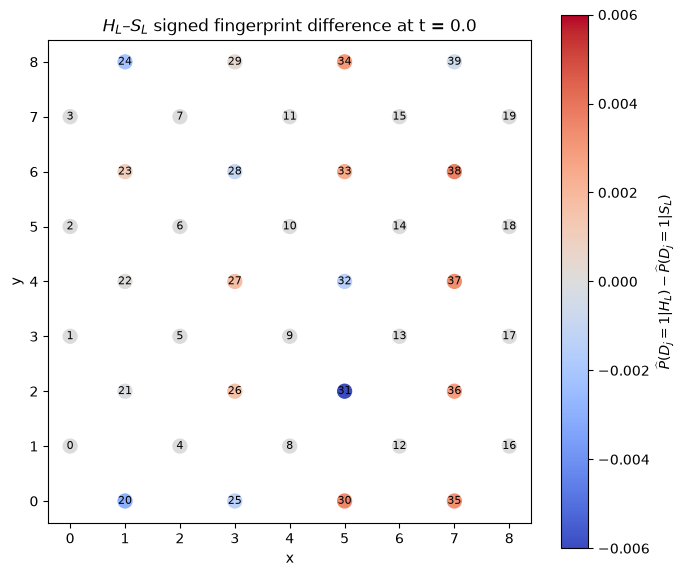

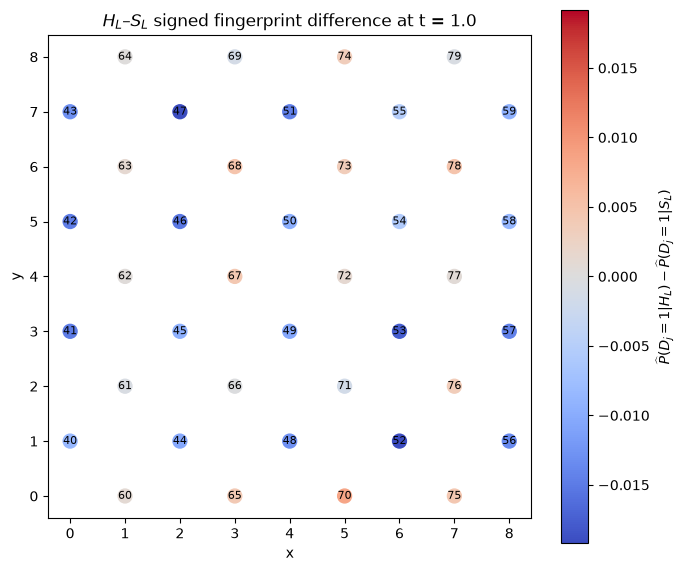

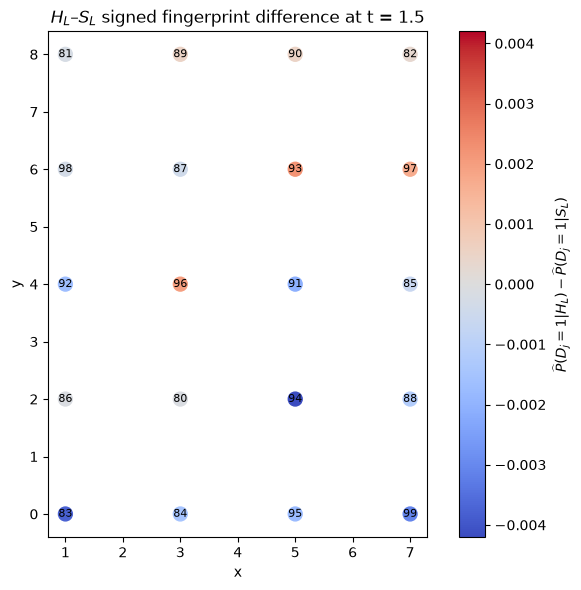

In [28]:
# Visualize the spatial structure of the H_L–S_L fingerprint difference
# separately for each temporal layer. Using the signed difference shows
# whether each detector has a higher event rate for H_L or for S_L.

signed_difference = h_event_rates - s_event_rates

for t in time_slices:
    layer_rows = [
        row for row in fingerprint_rows
        if row["t"] == t
    ]

    x = np.array([row["x"] for row in layer_rows])
    y = np.array([row["y"] for row in layer_rows])
    detector_ids = np.array([row["detector"] for row in layer_rows])
    delta = signed_difference[detector_ids]

    # Use a symmetric scale so that positive and negative differences
    # are visually comparable within each spacetime layer.
    max_abs_delta = np.max(np.abs(delta))

    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        x,
        y,
        c=delta,
        s=100,
        cmap="coolwarm",
        vmin=-max_abs_delta,
        vmax=max_abs_delta
    )

    for xi, yi, detector_id in zip(x, y, detector_ids):
        plt.text(
            xi,
            yi,
            str(detector_id),
            fontsize=8,
            ha="center",
            va="center"
        )

    plt.colorbar(
        scatter,
        label=r"$\widehat{P}(D_j=1|H_L)-\widehat{P}(D_j=1|S_L)$"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"$H_L$–$S_L$ signed fingerprint difference at t = {t}")
    plt.gca().set_aspect("equal")
    plt.tight_layout()
    plt.show()

**Interpretation of the spatial fingerprint difference**

The spatial maps show that the $H_L$–$S_L$ difference is strongly concentrated at the $t=1.0$ detector layer.

At $t=0.0$ and $t=1.5$, the signed differences are generally small and remain close to zero. In contrast, the $t=1.0$ layer contains a broader spatial pattern with several detectors showing substantially negative values.

For the signed difference

$$
\Delta_j
=
\widehat{P}(D_j=1\mid H_L)
-
\widehat{P}(D_j=1\mid S_L),
$$

a negative value means that the corresponding detector has a higher empirical event rate under $S_L$.

The spatial maps therefore show that the observed distinction between $H_L$ and $S_L$ is not confined to a single detector. Instead, multiple detectors in the $t=1.0$ layer contribute to the difference.

This result is a characterization of the simulated detector statistics. It does not, by itself, establish that a single noisy detector record is sufficient for reliable gate inference.

In [29]:
# Compare the complete H_L and S_L fingerprint vectors using several
# distribution-level measures. These quantify how similar or different
# the two empirical detector-event profiles are before classification.

h_centered = h_event_rates - h_event_rates.mean()
s_centered = s_event_rates - s_event_rates.mean()

pearson_correlation = np.corrcoef(
    h_event_rates,
    s_event_rates
)[0, 1]

euclidean_distance = np.linalg.norm(
    h_event_rates - s_event_rates
)

mean_absolute_difference = np.mean(
    np.abs(h_event_rates - s_event_rates)
)

l1_distance = np.sum(
    np.abs(h_event_rates - s_event_rates)
)

print("H_L vs S_L fingerprint comparison:")
print(f"Pearson correlation:      {pearson_correlation:.6f}")
print(f"Euclidean distance:       {euclidean_distance:.6f}")
print(f"Mean absolute difference: {mean_absolute_difference:.6f}")
print(f"L1 distance:              {l1_distance:.6f}")

H_L vs S_L fingerprint comparison:
Pearson correlation:      0.950529
Euclidean distance:       0.061401
Mean absolute difference: 0.003681
L1 distance:              0.368100


**Quantitative comparison of the $H_L$ and $S_L$ fingerprints**

The complete detector-event probability profiles for $H_L$ and $S_L$ are strongly correlated, with a Pearson correlation coefficient of

$$
r=0.950529.
$$

At the same time, the two profiles are not identical. Their mean absolute difference is

$$
\frac{1}{100}\sum_{j=1}^{100}
\left|
\widehat{P}(D_j=1\mid H_L)
-
\widehat{P}(D_j=1\mid S_L)
\right|
=
0.003681.
$$

The Euclidean and $L_1$ distances between the two 100-dimensional fingerprint vectors are

$$
\|\mathbf{p}_{H_L}-\mathbf{p}_{S_L}\|_2=0.061401
$$

and

$$
\|\mathbf{p}_{H_L}-\mathbf{p}_{S_L}\|_1=0.368100.
$$

These measurements show that the two gates produce similar overall detector-event profiles while retaining measurable detector-level differences.

The comparison is based on per-detector marginal event probabilities. It does not capture higher-order correlations among detectors within individual shots. Such correlations will be relevant when evaluating gate inference from complete detector records.

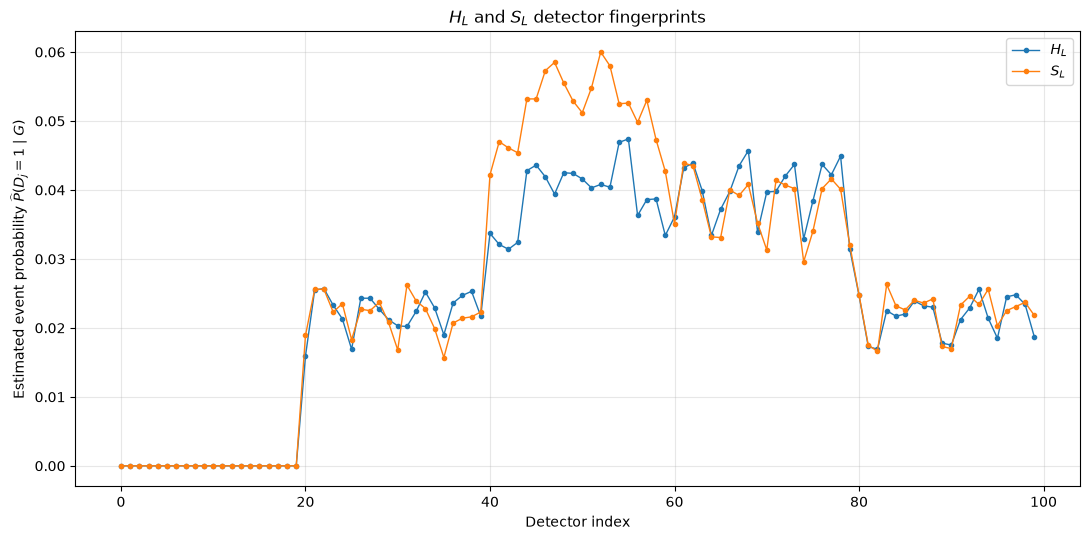

In [30]:
# Plot the two complete detector fingerprints on the same axes and scale.
# Each point corresponds to one detector, allowing direct visual comparison
# of the H_L and S_L event-rate profiles across the full detector frame.

detector_ids = np.arange(len(h_event_rates))

plt.figure(figsize=(11, 5.5))

plt.plot(
    detector_ids,
    h_event_rates,
    marker="o",
    markersize=3,
    linewidth=1,
    label=r"$H_L$"
)

plt.plot(
    detector_ids,
    s_event_rates,
    marker="o",
    markersize=3,
    linewidth=1,
    label=r"$S_L$"
)

plt.xlabel("Detector index")
plt.ylabel(r"Estimated event probability $\widehat{P}(D_j=1\mid G)$")
plt.title(r"$H_L$ and $S_L$ detector fingerprints")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**$H_L$ and $S_L$ detector fingerprints**

The detector-event probability profiles for $H_L$ and $S_L$ are shown across the 100 detectors.

The two profiles exhibit a similar overall structure, particularly outside the central operation layer. The first 20 detectors have zero estimated event probability for both gates, while the main increase in detector activity occurs over the detector range associated with the intermediate temporal layer.

The largest separation between the two profiles occurs in the central region, where the $S_L$ event probabilities are generally higher than those of $H_L$. This agrees with the temporal analysis, which identified $t=1.0$ as the layer containing the largest $H_L$–$S_L$ differences.

The plot therefore provides a direct visualization of the detector fingerprint: the logical gate affects the statistical pattern of detector events across the spacetime decoding record rather than producing a uniform change in detector activity.

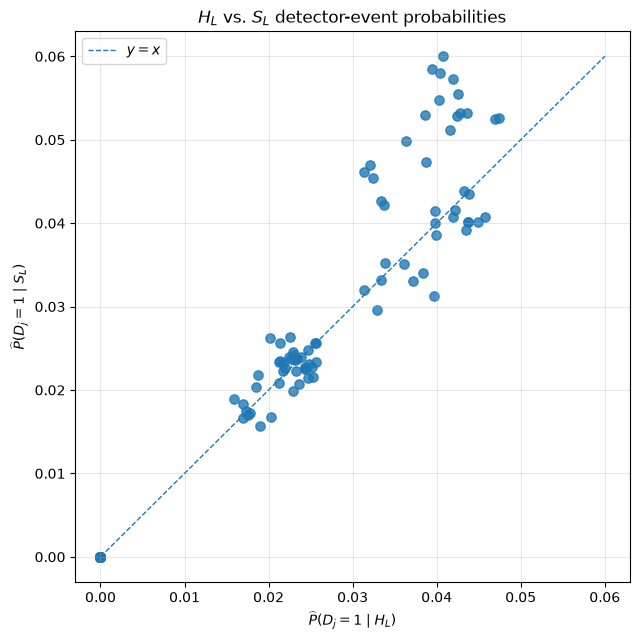

In [31]:
# Plot H_L event rates against S_L event rates.
# The diagonal y=x represents identical detector-event probabilities;
# deviations from this line show where the two fingerprints differ.

plt.figure(figsize=(6.5, 6.5))

plt.scatter(
    h_event_rates,
    s_event_rates,
    s=45,
    alpha=0.8
)

max_rate = max(
    h_event_rates.max(),
    s_event_rates.max()
)

plt.plot(
    [0, max_rate],
    [0, max_rate],
    linestyle="--",
    linewidth=1,
    label=r"$y=x$"
)

plt.xlabel(r"$\widehat{P}(D_j=1\mid H_L)$")
plt.ylabel(r"$\widehat{P}(D_j=1\mid S_L)$")
plt.title(r"$H_L$ vs. $S_L$ detector-event probabilities")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Detector-event probability comparison**

The scatter plot compares the estimated detector-event probabilities for $H_L$ and $S_L$ at corresponding detector locations.

The diagonal line

$$
y=x
$$

represents identical event probabilities for the two logical gates. Points close to this line correspond to detectors with similar empirical event rates, whereas deviations from the line indicate detector-level differences between $H_L$ and $S_L$.

Most detectors remain relatively close to the diagonal, consistent with the high Pearson correlation

$$
r=0.950529.
$$

However, a subset of detectors deviates noticeably from the diagonal, particularly in the higher-event-rate region. These deviations correspond to the localized differences identified in the spatial and temporal fingerprint analysis.

Thus, the two gates produce strongly correlated but non-identical detector-event probability profiles in the present simulation.

**Gate inference from complete detector records**

The marginal detector-event probabilities show measurable differences between $H_L$ and $S_L$. The next question is whether these differences can be exploited to infer the logical gate from an individual detector record.

Each sampled shot is represented by a binary vector

$$
\mathbf{d}^{(k)}
=
(D_1^{(k)},D_2^{(k)},\ldots,D_{100}^{(k)}),
$$

containing the outcomes of all 100 detectors.

We construct a binary classification problem with

$$
G\in\{H_L,S_L\}.
$$

The $H_L$ and $S_L$ records are combined and divided into training and test sets using a stratified 80/20 split. A Bernoulli Naive Bayes classifier is then trained on the complete detector records.

The purpose of this experiment is not to establish an optimal inference method, but to provide a simple baseline for testing whether the simulated detector records contain gate-dependent information that can be exploited for classification.

The resulting accuracy and confusion matrix will be compared with the $50\%$ chance level for this two-class problem.

In [32]:
# Combine the complete detector records from H_L and S_L into a binary
# classification dataset. Each shot remains intact as a 100-detector
# feature vector, allowing the classifier to use the full detector record.

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = np.vstack([h_samples, s_samples]).astype(int)

y = np.concatenate([
    np.zeros(len(h_samples), dtype=int),   # 0 = H_L
    np.ones(len(s_samples), dtype=int)     # 1 = S_L
])

print("Combined dataset shape:", X.shape)
print("Label vector shape:", y.shape)

print("\nClass counts:")
print(f"H_L: {np.sum(y == 0)}")
print(f"S_L: {np.sum(y == 1)}")

Combined dataset shape: (20000, 100)
Label vector shape: (20000,)

Class counts:
H_L: 10000
S_L: 10000


In [33]:
# Split the records into independent training and test sets while preserving
# the H_L/S_L class balance. The fixed random state makes the experiment
# reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class counts:")
print(f"H_L: {np.sum(y_train == 0)}")
print(f"S_L: {np.sum(y_train == 1)}")

print("\nTest class counts:")
print(f"H_L: {np.sum(y_test == 0)}")
print(f"S_L: {np.sum(y_test == 1)}")

Training set: (16000, 100)
Test set: (4000, 100)

Training class counts:
H_L: 8000
S_L: 8000

Test class counts:
H_L: 2000
S_L: 2000


**Training and test sets**

The combined dataset contains $20{,}000$ complete detector records, with an equal number of samples from the two logical gates:

$$
N_{H_L}=N_{S_L}=10{,}000.
$$

A stratified 80/20 split produces

$$
N_{\mathrm{train}}=16{,}000,
\qquad
N_{\mathrm{test}}=4{,}000.
$$

Both subsets remain class-balanced:

$$
N_{H_L}^{\mathrm{train}}
=
N_{S_L}^{\mathrm{train}}
=
8{,}000,
$$

and

$$
N_{H_L}^{\mathrm{test}}
=
N_{S_L}^{\mathrm{test}}
=
2{,}000.
$$

The classifier will therefore be evaluated on an equally balanced two-class test set, making $50\%$ the corresponding chance-level accuracy.

In [34]:
# Train a Bernoulli Naive Bayes classifier on the complete detector records.
# Each detector is treated as a binary feature, and the classifier learns
# the gate-dependent probability of observing detector events from the
# training shots.

classifier = BernoulliNB()

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}")

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["H_L", "S_L"],
        digits=4
    )
)

Test accuracy: 0.5527

Confusion matrix:
[[1290  710]
 [1079  921]]

Classification report:
              precision    recall  f1-score   support

         H_L     0.5445    0.6450    0.5905      2000
         S_L     0.5647    0.4605    0.5073      2000

    accuracy                         0.5527      4000
   macro avg     0.5546    0.5528    0.5489      4000
weighted avg     0.5546    0.5527    0.5489      4000



**Baseline gate-inference result**

A Bernoulli Naive Bayes classifier was trained using the complete 100-detector records.

On the balanced test set of $4{,}000$ shots, the classifier achieved an accuracy of

$$
\mathrm{Accuracy}=0.5527
$$

corresponding to 2,211 correctly classified detector records.

The confusion matrix is

$$
\begin{pmatrix}
1290 & 710\\
1079 & 921
\end{pmatrix},
$$

where rows correspond to the true gate and columns correspond to the predicted gate.

For $H_L$, the classifier achieved

$$
\mathrm{Precision}=0.5445,
\qquad
\mathrm{Recall}=0.6450,
\qquad
F_1=0.5905.
$$

For $S_L$, the corresponding values are

$$
\mathrm{Precision}=0.5647,
\qquad
\mathrm{Recall}=0.4605,
\qquad
F_1=0.5073.
$$

The classifier therefore distinguishes the two gates above the $50\%$ chance level in this particular test split, while showing asymmetric performance between the two classes.

Because the test set contains independent noisy detector records but the accuracy is only modestly above chance, a statistical uncertainty analysis is required before interpreting the result as evidence of reliable gate inference.

In [44]:
# Compute both a two-sided 95% confidence interval for the observed
# accuracy and a one-sided exact binomial test against the 50% chance level.
# The two-sided interval is used for reporting the uncertainty around the
# measured accuracy, while the one-sided test evaluates accuracy > 0.50.

from scipy.stats import binomtest

n_test = len(y_test)
n_correct = np.sum(y_pred == y_test)

accuracy = n_correct / n_test

# Two-sided confidence interval for reporting the uncertainty of accuracy.
two_sided_test = binomtest(
    n_correct,
    n=n_test,
    p=0.5,
    alternative="two-sided"
)

ci = two_sided_test.proportion_ci(
    confidence_level=0.95,
    method="wilson"
)

# One-sided exact test for whether accuracy exceeds chance level.
greater_test = binomtest(
    n_correct,
    n=n_test,
    p=0.5,
    alternative="greater"
)

accuracy_lift = accuracy - 0.50

print("Statistical analysis of classification accuracy:")
print(f"Correct predictions: {n_correct} / {n_test}")
print(f"Observed accuracy: {accuracy:.6f}")
print(f"Accuracy above chance: {accuracy_lift:.6f}")

print("\n95% two-sided Wilson confidence interval:")
print(f"[{ci.low:.6f}, {ci.high:.6f}]")

print("\nOne-sided exact binomial test against 50%:")
print(f"p-value: {greater_test.pvalue:.6g}")

Statistical analysis of classification accuracy:
Correct predictions: 2211 / 4000
Observed accuracy: 0.552750
Accuracy above chance: 0.052750

95% two-sided Wilson confidence interval:
[0.537298, 0.568100]

One-sided exact binomial test against 50%:
p-value: 1.3449e-11


**Statistical assessment of the baseline inference result**

The Bernoulli Naive Bayes classifier achieved an accuracy of

$$
\mathrm{Accuracy}=0.55275
$$

on the balanced test set of $4{,}000$ detector records, corresponding to 2,211 correct predictions.

For a two-class balanced problem, the chance-level accuracy is $0.50$. An exact one-sided binomial test against this chance level gives

$$
p=1.3449\times10^{-11}.
$$

The corresponding two-sided 95% Wilson confidence interval for the observed accuracy is approximately

$$
[0.5373,\;0.5681].
$$

Thus, the observed accuracy is statistically above the $50\%$ chance level for this test set. This indicates that the Bernoulli Naive Bayes model is able to exploit some gate-dependent statistical structure in the simulated $H_L$ and $S_L$ detector records.

However, the effect is modest: the measured accuracy is only $5.27$ percentage points above chance, and the classifier performance is asymmetric between the two gates. Therefore, this result should be interpreted as evidence of detectable gate-dependent structure rather than as reliable single-shot gate identification.

Further analysis is required to determine how robust this effect is to changes in the train/test split, noise realization, and inference method.

**Robustness across train/test splits**

The initial Bernoulli Naive Bayes result was obtained from a single stratified 80/20 train/test split using `random_state=42`.

Because classification accuracy can depend on the particular partition of the finite dataset, we next repeat the same experiment across multiple random seeds.

For each split:

1. the same balanced dataset is divided into training and test sets using an 80/20 stratified split;
2. a new Bernoulli Naive Bayes classifier is trained on the training records;
3. accuracy is evaluated on the corresponding test records.

We use 10 random seeds to estimate the variability of the observed classification accuracy.

The resulting mean and standard deviation characterize the variation across these splits. A 95% confidence interval for the mean accuracy across the 10 splits is also reported.

This analysis tests the robustness of the observed gate-inference baseline rather than relying on a single train/test partition.

In [38]:
# Repeat the H_L vs S_L classification experiment across 10 different
# stratified train/test splits. The classifier and dataset are kept fixed;
# only the partition of the available detector records changes.

seeds = range(42, 52)
split_accuracies = []

for seed in seeds:
    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    model = BernoulliNB()
    model.fit(X_train_seed, y_train_seed)

    y_pred_seed = model.predict(X_test_seed)
    accuracy_seed = accuracy_score(y_test_seed, y_pred_seed)

    split_accuracies.append(accuracy_seed)

    print(f"Seed {seed}: accuracy = {accuracy_seed:.4f}")

# Convert to NumPy for the summary statistics.
split_accuracies = np.array(split_accuracies)

mean_accuracy = split_accuracies.mean()
std_accuracy = split_accuracies.std(ddof=1)

# 95% confidence interval for the mean accuracy across the 10 splits.
from scipy.stats import t

n_splits = len(split_accuracies)
standard_error = std_accuracy / np.sqrt(n_splits)
t_critical = t.ppf(0.975, df=n_splits - 1)

ci_low = mean_accuracy - t_critical * standard_error
ci_high = mean_accuracy + t_critical * standard_error

print("\nRobustness summary:")
print(f"Mean accuracy: {mean_accuracy:.4f}")
print(f"Standard deviation: {std_accuracy:.4f}")
print(f"Minimum accuracy: {split_accuracies.min():.4f}")
print(f"Maximum accuracy: {split_accuracies.max():.4f}")
print(f"95% CI for mean accuracy: [{ci_low:.4f}, {ci_high:.4f}]")

Seed 42: accuracy = 0.5527
Seed 43: accuracy = 0.5413
Seed 44: accuracy = 0.5305
Seed 45: accuracy = 0.5252
Seed 46: accuracy = 0.5383
Seed 47: accuracy = 0.5395
Seed 48: accuracy = 0.5262
Seed 49: accuracy = 0.5395
Seed 50: accuracy = 0.5232
Seed 51: accuracy = 0.5310

Robustness summary:
Mean accuracy: 0.5348
Standard deviation: 0.0091
Minimum accuracy: 0.5232
Maximum accuracy: 0.5527
95% CI for mean accuracy: [0.5282, 0.5413]


**Robustness across random train/test splits**

To assess whether the gate-inference result depends strongly on a particular train/test split, the Bernoulli Naive Bayes experiment was repeated using ten different random seeds.

The measured accuracies were

$$
\{0.5527,\;0.5413,\;0.5305,\;0.5252,\;0.5383,\;
0.5395,\;0.5262,\;0.5395,\;0.5232,\;0.5310\}.
$$

Across ten different stratified train/test splits, the mean accuracy was, the mean accuracy was

$$
\overline{A}=0.5348,
$$

with a standard deviation of

$$
\sigma_A=0.0091.
$$

The observed range was

$$
0.5232\leq A\leq0.5527.
$$

The 95% confidence interval for the mean accuracy across the ten seeds was

$$
[0.5282,\;0.5413].
$$

All tested random seeds produced accuracies above the $50\%$ chance level. The result is therefore not confined to the original seed-42 train/test partition.

However, the average improvement over chance is modest:

$$
0.5348-0.5000=0.0348.
$$

The robustness experiment therefore supports the presence of a reproducible but relatively weak gate-dependent classification signal in the present $H_L$/$S_L$ simulation.

This remains a baseline result rather than a claim of reliable practical gate reconstruction.

**Label-permutation control**

A label-permutation control is used to test whether the observed classification performance depends on the actual correspondence between detector records and logical-gate labels.

The detector records are kept unchanged, while the gate labels are randomly permuted. The same train/test procedure and Bernoulli Naive Bayes classifier are then applied to the permuted dataset.

Under the null hypothesis that the labels contain no information about the detector records, the expected classification accuracy is approximately the two-class chance level,

$$
A_{\mathrm{chance}}=0.5.
$$

A permutation result near $50\%$ provides a control indicating that above-chance performance in the original experiment is associated with the original gate labels rather than arising from the classification procedure alone.

In [39]:
# Break the association between detector records and gate labels while keeping
# the detector data unchanged. This provides a null-control experiment for the
# original gate-inference result.

rng = np.random.default_rng(42)

y_permuted = rng.permutation(y)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_permuted,
    test_size=0.20,
    stratify=y_permuted,
    random_state=42
)

permuted_classifier = BernoulliNB()
permuted_classifier.fit(X_train_p, y_train_p)

y_pred_p = permuted_classifier.predict(X_test_p)

permuted_accuracy = accuracy_score(
    y_test_p,
    y_pred_p
)

print(f"Permuted-label accuracy: {permuted_accuracy:.4f}")

Permuted-label accuracy: 0.5002


**Permutation-label sanity check**

As a control experiment, the gate labels were randomly permuted before training and evaluation.

The resulting classification accuracy was

$$
\mathrm{Accuracy}_{\mathrm{permuted}}=0.5002.
$$

This value is approximately the $50\%$ chance level expected for a balanced two-class problem.

In contrast, the classifier trained with the original gate labels achieved

$$
\mathrm{Accuracy}_{\mathrm{original}}=0.5527.
$$

The permutation control therefore removes the above-chance performance observed with the original labels. This supports the interpretation that the classifier's performance is associated with structure in the detector records rather than arising simply from the classification procedure itself.

The measured accuracy difference is

$$
0.5527-0.5002=0.0525,
$$

corresponding to a 5.25-percentage-point difference between the original-label and permuted-label experiments.

The permutation test is a control for label association; it does not by itself quantify the physical origin of the gate-dependent detector structure.

**Detector-level contribution to gate inference**

The previous analysis established that the detector records contain information associated with the logical-gate label. We now examine which detectors contribute most strongly to the Bernoulli Naive Bayes decision.

For detector $j$, the classifier estimates the class-conditional probabilities

$$
P(D_j=1\mid H_L)
\qquad\text{and}\qquad
P(D_j=1\mid S_L).
$$

A detector is potentially more informative when its estimated event probability differs substantially between the two classes.

We therefore rank detectors using the absolute difference

$$
\left|
P(D_j=1\mid H_L)
-
P(D_j=1\mid S_L)
\right|,
$$

and compare the resulting detector locations with the previously identified spatial and temporal fingerprint differences.

This analysis connects the statistical gate-inference result to specific spacetime detector locations.

In [40]:
# Rank detectors by the magnitude of the class-conditional probability
# difference learned by the Bernoulli Naive Bayes classifier. This identifies
# which detector features have the strongest gate-dependent statistics.

nb_h_rates = np.exp(classifier.feature_log_prob_[0])
nb_s_rates = np.exp(classifier.feature_log_prob_[1])

nb_difference = np.abs(nb_h_rates - nb_s_rates)

top_nb_detectors = np.argsort(nb_difference)[::-1][:10]

print("Top 10 detectors by Naive Bayes class-conditional difference:\n")

for detector_id in top_nb_detectors:
    coord = np.asarray(h_detector_coords[detector_id])

    print(
        f"Detector {detector_id:2d} | "
        f"(x, y, t)=({coord[0]}, {coord[1]}, {coord[2]}) | "
        f"H_L={nb_h_rates[detector_id]:.4f} | "
        f"S_L={nb_s_rates[detector_id]:.4f} | "
        f"|Δ|={nb_difference[detector_id]:.4f}"
    )

Top 10 detectors by Naive Bayes class-conditional difference:

Detector 47 | (x, y, t)=(2.0, 7.0, 1.0) | H_L=0.0389 | S_L=0.0589 | |Δ|=0.0200
Detector 52 | (x, y, t)=(6.0, 1.0, 1.0) | H_L=0.0404 | S_L=0.0596 | |Δ|=0.0192
Detector 53 | (x, y, t)=(6.0, 3.0, 1.0) | H_L=0.0415 | S_L=0.0575 | |Δ|=0.0160
Detector 56 | (x, y, t)=(8.0, 1.0, 1.0) | H_L=0.0362 | S_L=0.0507 | |Δ|=0.0145
Detector 51 | (x, y, t)=(4.0, 7.0, 1.0) | H_L=0.0409 | S_L=0.0552 | |Δ|=0.0144
Detector 41 | (x, y, t)=(0.0, 3.0, 1.0) | H_L=0.0321 | S_L=0.0465 | |Δ|=0.0144
Detector 46 | (x, y, t)=(2.0, 5.0, 1.0) | H_L=0.0416 | S_L=0.0557 | |Δ|=0.0141
Detector 57 | (x, y, t)=(8.0, 3.0, 1.0) | H_L=0.0396 | S_L=0.0534 | |Δ|=0.0137
Detector 48 | (x, y, t)=(4.0, 1.0, 1.0) | H_L=0.0424 | S_L=0.0552 | |Δ|=0.0129
Detector 42 | (x, y, t)=(0.0, 5.0, 1.0) | H_L=0.0332 | S_L=0.0454 | |Δ|=0.0121


**Detector-level features contributing to gate inference**

The Bernoulli Naive Bayes model assigns different class-conditional event probabilities to the detectors. The detectors with the largest absolute differences between the learned $H_L$ and $S_L$ conditional probabilities are concentrated at the intermediate temporal layer

$$
t=1.0.
$$

The strongest difference occurs at detector 47,

$$
(x,y,t)=(2,7,1.0),
$$

for which the learned class-conditional event probabilities are

$$
\widehat{P}(D_{47}=1\mid H_L)=0.0389,
$$

and

$$
\widehat{P}(D_{47}=1\mid S_L)=0.0589.
$$

The remaining high-difference detectors are similarly concentrated at $t=1.0$.

Importantly, most of these detectors overlap with those identified independently from the raw fingerprint comparison. This indicates that the classifier is exploiting detector-level statistical differences that are already visible in the empirical $H_L$ and $S_L$ fingerprints.

The result supports the interpretation that the measured classification performance is associated with structured gate-dependent detector statistics rather than a difference in the global class frequencies.

In [41]:
# Train a Bernoulli Naive Bayes classifier on the complete detector records.
# Each detector is treated as a binary feature, and the classifier learns
# the gate-dependent probability of observing detector events from the
# training shots.

classifier = BernoulliNB()

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}")

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["H_L", "S_L"],
        digits=4
    )
)

Test accuracy: 0.5527

Confusion matrix:
[[1290  710]
 [1079  921]]

Classification report:
              precision    recall  f1-score   support

         H_L     0.5445    0.6450    0.5905      2000
         S_L     0.5647    0.4605    0.5073      2000

    accuracy                         0.5527      4000
   macro avg     0.5546    0.5528    0.5489      4000
weighted avg     0.5546    0.5527    0.5489      4000



**Baseline gate-inference result**

A Bernoulli Naive Bayes classifier was trained using the complete 100-detector records.

On the balanced test set of $4{,}000$ shots, the classifier achieved an accuracy of

$$
\mathrm{Accuracy}=0.5527
$$

corresponding to 2,211 correctly classified detector records.

The confusion matrix is

$$
\begin{pmatrix}
1290 & 710\\
1079 & 921
\end{pmatrix},
$$

where rows correspond to the true gate and columns correspond to the predicted gate.

For $H_L$, the classifier achieved

$$
\mathrm{Precision}=0.5445,
\qquad
\mathrm{Recall}=0.6450,
\qquad
F_1=0.5905.
$$

For $S_L$, the corresponding values are

$$
\mathrm{Precision}=0.5647,
\qquad
\mathrm{Recall}=0.4605,
\qquad
F_1=0.5073.
$$

The classifier therefore distinguishes the two gates above the $50\%$ chance level in this particular test split, while showing asymmetric performance between the two classes.

Because the test set contains independent noisy detector records but the accuracy is only modestly above chance, a statistical uncertainty analysis is required before interpreting the result as evidence of reliable gate inference.

**Extension of the inference analysis**

The initial $H_L$–$S_L$ experiment shows a measurable difference between the two detector-record distributions, while the single train/test split provides only a baseline estimate of gate-inference performance.

The following experiments extend this analysis by testing the robustness and statistical validity of the observed signal before drawing final conclusions.

**Robustness of the gate-inference result**

A single train/test split can produce an accuracy that depends partly on the particular samples assigned to the training and test sets.

To assess the stability of the observed $H_L$ versus $S_L$ inference performance, the Bernoulli Naive Bayes classifier is therefore evaluated using stratified $5$-fold cross-validation.

In each fold, the class balance between $H_L$ and $S_L$ is preserved. The classifier is trained on four folds and evaluated on the remaining fold.

The resulting accuracies are summarized by their mean and standard deviation:

$$
\bar{A}
=
\frac{1}{K}\sum_{k=1}^{K}A_k,
\qquad K=5,
$$

and

$$
\sigma_A
=
\sqrt{
\frac{1}{K-1}
\sum_{k=1}^{K}
(A_k-\bar{A})^2
}.
$$

This provides a more robust estimate of the baseline's performance than a single train/test split.

In [45]:
# Evaluate Bernoulli Naive Bayes across five stratified folds.
# This checks whether the approximately 55% accuracy observed in the
# original split is stable across different train/test partitions.

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_classifier = BernoulliNB()

cv_scores = cross_val_score(
    cv_classifier,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("5-fold cross-validation accuracies:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nCross-validation summary:")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std(ddof=1):.4f}")
print(f"Chance level: 0.5000")

5-fold cross-validation accuracies:
Fold 1: 0.5350
Fold 2: 0.5225
Fold 3: 0.5410
Fold 4: 0.5288
Fold 5: 0.5427

Cross-validation summary:
Mean accuracy: 0.5340
Standard deviation: 0.0085
Chance level: 0.5000


**Five-fold cross-validation**

To assess the stability of the Bernoulli Naive Bayes baseline, five-fold stratified cross-validation was performed on the complete $H_L/S_L$ dataset.

The fold accuracies were

$$
0.5350,\quad
0.5225,\quad
0.5410,\quad
0.5288,\quad
0.5427.
$$

The resulting mean accuracy was

$$
\bar{A}=0.5340,
$$

with a standard deviation of

$$
\sigma_A=0.0085.
$$

The mean accuracy is above the two-class chance level of

$$
A_{\mathrm{chance}}=0.5000,
$$

but the absolute improvement is modest:

$$
\bar{A}-A_{\mathrm{chance}}=0.0340.
$$

The relatively small fold-to-fold variation indicates that the baseline performance is reasonably consistent across the five splits. However, the cross-validation result remains close to chance and should therefore be interpreted as evidence of a weak but measurable gate-dependent signal rather than as reliable gate identification.

The cross-validation estimate is also lower than the previously observed single holdout accuracy of $0.5527$, highlighting the importance of evaluating the classifier over multiple train/test partitions.

**Detector contribution to gate inference**

The preceding analysis established that the $H_L$ and $S_L$ detector-event profiles differ, particularly at the $t=1.0$ layer. We now examine whether the classifier relies on the same detectors when performing gate inference.

For Bernoulli Naive Bayes, each binary detector feature has class-conditional probabilities for observing an event and no event. The relative contribution of detector $j$ can be characterized from the difference between the learned log-probability parameters for the two classes.

A large magnitude of this quantity indicates that detector $j$ provides a stronger contribution to the class-conditional model.

The resulting detector contributions are mapped back to the spacetime coordinates $(x,y,t)$ to determine whether the detectors most useful for inference are spatially and temporally localized in the same region as the empirical $H_L$–$S_L$ fingerprint differences.

In [46]:
# Extract the learned detector-level log-probability differences from
# Bernoulli Naive Bayes. Large magnitudes indicate detectors whose binary
# outcomes contribute more strongly to separating H_L from S_L.

log_prob = classifier.feature_log_prob_

# Class 0 = H_L, Class 1 = S_L
detector_contribution = log_prob[1] - log_prob[0]

absolute_contribution = np.abs(detector_contribution)

# Rank detectors by the magnitude of their learned contribution.
ranked_detectors = np.argsort(
    absolute_contribution
)[::-1]

print("Top 10 detectors by classifier contribution:\n")

for detector_id in ranked_detectors[:10]:
    coord = np.asarray(h_detector_coords[detector_id])

    print(
        f"Detector {detector_id:2d} | "
        f"(x, y, t)=({coord[0]}, {coord[1]}, {coord[2]}) | "
        f"log-probability difference="
        f"{detector_contribution[detector_id]:+.6f} | "
        f"|contribution|={absolute_contribution[detector_id]:.6f}"
    )

Top 10 detectors by classifier contribution:

Detector 47 | (x, y, t)=(2.0, 7.0, 1.0) | log-probability difference=+0.415065 | |contribution|=0.415065
Detector 52 | (x, y, t)=(6.0, 1.0, 1.0) | log-probability difference=+0.389864 | |contribution|=0.389864
Detector 41 | (x, y, t)=(0.0, 3.0, 1.0) | log-probability difference=+0.369818 | |contribution|=0.369818
Detector 56 | (x, y, t)=(8.0, 1.0, 1.0) | log-probability difference=+0.336472 | |contribution|=0.336472
Detector 53 | (x, y, t)=(6.0, 3.0, 1.0) | log-probability difference=+0.326092 | |contribution|=0.326092
Detector 42 | (x, y, t)=(0.0, 5.0, 1.0) | log-probability difference=+0.310907 | |contribution|=0.310907
Detector 51 | (x, y, t)=(4.0, 7.0, 1.0) | log-probability difference=+0.301350 | |contribution|=0.301350
Detector 57 | (x, y, t)=(8.0, 3.0, 1.0) | log-probability difference=+0.297882 | |contribution|=0.297882
Detector 43 | (x, y, t)=(0.0, 7.0, 1.0) | log-probability difference=+0.294167 | |contribution|=0.294167
Detector 

**Classifier-contributing detectors**

The Bernoulli Naive Bayes classifier assigns different log-probability contributions to the detector features when distinguishing $H_L$ from $S_L$.

The detectors with the largest absolute contributions are concentrated at

$$
t=1.0.
$$

For example, detector 47 has the largest absolute contribution,

$$
|\Delta\log P|=0.415065,
$$

followed by detector 52 with

$$
|\Delta\log P|=0.389864.
$$

These detectors are also among those with the largest differences in empirical detector-event probabilities between $H_L$ and $S_L$.

The spatial and statistical overlap between the two analyses indicates that the classifier is relying on detector locations where the two gate-conditioned event rates differ most strongly.

The signed log-probability difference indicates the direction of the classifier contribution according to the convention defined in the preceding analysis, while its magnitude quantifies how strongly the detector contributes to the class likelihood comparison.

In [48]:
# Extract the Bernoulli Naive Bayes log-probabilities for detector events.
# Class 0 corresponds to H_L and class 1 corresponds to S_L.
# The difference gives the learned gate-dependent contrast for D_j = 1.

log_probability_difference = (
    classifier.feature_log_prob_[1]
    - classifier.feature_log_prob_[0]
)

print("Log-probability difference shape:", log_probability_difference.shape)

print("\nFirst 10 log-probability differences:")
print(log_probability_difference[:10])

Log-probability difference shape: (100,)

First 10 log-probability differences:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Temporal localization of the learned gate-dependent contrast**

We now examine the magnitude of the learned log-probability contrast across the three detector time layers.

For each temporal layer, we calculate

$$
\overline{|L|}_t
=
\frac{1}{N_t}
\sum_{j\in t}|L_j|,
$$

where $N_t$ is the number of detectors in that layer.

This identifies the spacetime regions in which the classifier has learned the largest differences in detector-event probabilities between $H_L$ and $S_L$.

In [49]:
# Quantify the magnitude of the learned gate-dependent log-probability
# contrast separately for each temporal layer.

classifier_contribution = np.abs(log_probability_difference)

print("Learned log-probability contrast by temporal layer:\n")

for t in time_slices:
    layer_rows = [
        row for row in fingerprint_rows
        if row["t"] == t
    ]

    detector_ids_layer = np.array(
        [row["detector"] for row in layer_rows]
    )

    layer_contrast = classifier_contribution[
        detector_ids_layer
    ]

    print(
        f"t = {t}: "
        f"detectors = {len(layer_contrast)}, "
        f"mean |L| = {layer_contrast.mean():.6f}, "
        f"max |L| = {layer_contrast.max():.6f}"
    )

Learned log-probability contrast by temporal layer:

t = 0.0: detectors = 40, mean |L| = 0.050991, max |L| = 0.244302
t = 1.0: detectors = 40, mean |L| = 0.160990, max |L| = 0.415065
t = 1.5: detectors = 20, mean |L| = 0.073847, max |L| = 0.197977


**Learned detector-level log-probability contrast**

The Bernoulli Naive Bayes model provides a detector-level measure of how strongly each binary detector feature contributes differently to the two gate classes.

The resulting log-probability contrast contains 100 detector-specific values. The first 10 detectors have zero contrast, consistent with their zero observed event rates for both $H_L$ and $S_L$.

The magnitude of the learned contrast is summarized for each temporal layer by

$$
|L_j|,
$$

where $L_j$ denotes the learned log-probability contrast for detector $j$.

The mean absolute contrast is

$$
\overline{|L|}
=
0.050991
\quad (t=0),
$$

$$
\overline{|L|}
=
0.160990
\quad (t=1),
$$

and

$$
\overline{|L|}
=
0.073847
\quad (t=1.5).
$$

The largest absolute contrast is also observed at $t=1.0$:

$$
\max |L| = 0.415065.
$$

Thus, the statistical information learned by the classifier is concentrated primarily in the $t=1.0$ detector layer. This agrees with the earlier detector-event analysis, where the largest $H_L$–$S_L$ differences were also localized at $t=1.0$.

This provides a link between the detector fingerprint characterization and the gate-inference result: the detectors showing the largest empirical differences are also located in the temporal region where the classifier learns the strongest gate-dependent probability contrast.

In [50]:
# Rank detectors by the magnitude of the learned log-probability contrast.
# This identifies which detector locations provide the strongest
# gate-dependent statistical evidence to the Naive Bayes classifier.

abs_log_contrast = np.abs(log_probability_difference)

ranked_detector_ids = np.argsort(
    abs_log_contrast
)[::-1]

print("Top 10 detectors by |learned log-probability contrast|:\n")

for detector_id in ranked_detector_ids[:10]:
    coord = np.asarray(h_detector_coords[detector_id])

    print(
        f"Detector {detector_id:2d} | "
        f"(x, y, t)=({coord[0]}, {coord[1]}, {coord[2]}) | "
        f"L={log_probability_difference[detector_id]:+.6f} | "
        f"|L|={abs_log_contrast[detector_id]:.6f}"
    )

Top 10 detectors by |learned log-probability contrast|:

Detector 47 | (x, y, t)=(2.0, 7.0, 1.0) | L=+0.415065 | |L|=0.415065
Detector 52 | (x, y, t)=(6.0, 1.0, 1.0) | L=+0.389864 | |L|=0.389864
Detector 41 | (x, y, t)=(0.0, 3.0, 1.0) | L=+0.369818 | |L|=0.369818
Detector 56 | (x, y, t)=(8.0, 1.0, 1.0) | L=+0.336472 | |L|=0.336472
Detector 53 | (x, y, t)=(6.0, 3.0, 1.0) | L=+0.326092 | |L|=0.326092
Detector 42 | (x, y, t)=(0.0, 5.0, 1.0) | L=+0.310907 | |L|=0.310907
Detector 51 | (x, y, t)=(4.0, 7.0, 1.0) | L=+0.301350 | |L|=0.301350
Detector 57 | (x, y, t)=(8.0, 3.0, 1.0) | L=+0.297882 | |L|=0.297882
Detector 43 | (x, y, t)=(0.0, 7.0, 1.0) | L=+0.294167 | |L|=0.294167
Detector 46 | (x, y, t)=(2.0, 5.0, 1.0) | L=+0.292176 | |L|=0.292176


**Detector contributions to gate inference**

The Bernoulli Naive Bayes classifier provides a detector-level likelihood contrast that indicates which detector features contribute most strongly to the distinction between $H_L$ and $S_L$.

The detectors were ranked according to the absolute value of their learned log-probability contrast,

$$
|L_j|.
$$

The ten detectors with the largest values are all located at the temporal layer

$$
t=1.0.
$$

The largest contrasts are observed for detectors 47 and 52, with

$$
L_{47}=0.415065,
\qquad
L_{52}=0.389864.
$$

The remaining highly informative detectors are also concentrated in the same temporal layer.

This result agrees with the earlier marginal-event analysis, where the $t=1.0$ layer exhibited the largest mean and maximum $H_L$–$S_L$ event-rate differences. The agreement between the marginal fingerprint analysis and the learned classifier weights provides consistent evidence that the intermediate detector layer contains most of the gate-dependent information used by the present Bernoulli Naive Bayes model.

The log-probability contrast is a property of the trained classifier and should therefore be interpreted as a model-based measure of detector informativeness rather than as a direct measure of the underlying physical distinguishability of the two logical gates.

**Independent fresh-shot validation**

The initial gate-inference experiment used an 80/20 split of the sampled detector records.

To test whether the observed classification performance generalizes beyond this particular train/test partition, an independent validation set is generated directly from the encoded $H_L$ and $S_L$ experiments.

The classifier is trained using the previously constructed training set and evaluated on newly sampled detector records that were not used during model training or the initial test split.

This provides an independent check of whether gate-dependent information remains detectable in previously unseen detector records.

In [54]:
# Generate a completely fresh validation set from the H_L and S_L experiments.
# These shots are independent of the records used in the original train/test split.

FRESH_SHOTS = 5_000

h_fresh = h_experiment.compile_detector_sampler().sample(shots=FRESH_SHOTS)
s_fresh = s_experiment.compile_detector_sampler().sample(shots=FRESH_SHOTS)

X_fresh = np.vstack([h_fresh, s_fresh]).astype(int)

y_fresh = np.concatenate([
    np.zeros(FRESH_SHOTS, dtype=int),   # 0 = H_L
    np.ones(FRESH_SHOTS, dtype=int)     # 1 = S_L
])

print("Fresh validation dataset shape:", X_fresh.shape)
print("Fresh validation labels shape:", y_fresh.shape)

print("\nFresh validation class counts:")
print(f"H_L: {np.sum(y_fresh == 0)}")
print(f"S_L: {np.sum(y_fresh == 1)}")

Fresh validation dataset shape: (10000, 100)
Fresh validation labels shape: (10000,)

Fresh validation class counts:
H_L: 5000
S_L: 5000


**Evaluation on independently generated detector records**

The validation set contains $5{,}000$ newly generated records for each logical gate, giving

$$
N_{\mathrm{validation}}=10{,}000.
$$

The previously trained Bernoulli Naive Bayes model is evaluated without retraining on these new records.

Because the validation data are generated independently from the training and initial test records, the resulting accuracy provides an additional measure of the generalization of gate inference to unseen detector shots.

In [55]:
# Evaluate the already trained classifier on the independently generated
# validation records. The model is not retrained, so this measures
# generalization to completely new detector shots.

y_fresh_pred = classifier.predict(X_fresh)

fresh_accuracy = accuracy_score(
    y_fresh,
    y_fresh_pred
)

fresh_cm = confusion_matrix(
    y_fresh,
    y_fresh_pred
)

print(f"Fresh validation accuracy: {fresh_accuracy:.4f}")

print("\nFresh validation confusion matrix:")
print(fresh_cm)

print("\nFresh validation classification report:")
print(
    classification_report(
        y_fresh,
        y_fresh_pred,
        target_names=["H_L", "S_L"],
        digits=4
    )
)

Fresh validation accuracy: 0.5374

Fresh validation confusion matrix:
[[3143 1857]
 [2769 2231]]

Fresh validation classification report:
              precision    recall  f1-score   support

         H_L     0.5316    0.6286    0.5761      5000
         S_L     0.5457    0.4462    0.4910      5000

    accuracy                         0.5374     10000
   macro avg     0.5387    0.5374    0.5335     10000
weighted avg     0.5387    0.5374    0.5335     10000



**Fresh validation result**

The trained Bernoulli Naive Bayes classifier was evaluated on a fresh validation set containing $10{,}000$ independently sampled detector records, with $5{,}000$ records from each logical gate.

The validation accuracy was

$$
\mathrm{Accuracy}_{\mathrm{fresh}}=0.5374.
$$

Thus, the classifier correctly identified

$$
5374
$$

of the $10{,}000$ detector records.

Compared with the original held-out test accuracy of $55.27\%$, the fresh-validation accuracy is lower by

$$
55.27\%-53.74\%=1.53
$$

percentage points.

The confusion matrix shows asymmetric classification performance:

$$
\begin{pmatrix}
3143 & 1857\\
2769 & 2231
\end{pmatrix}.
$$

The corresponding recalls are

$$
\mathrm{Recall}(H_L)=0.6286,
\qquad
\mathrm{Recall}(S_L)=0.4462.
$$

Therefore, the classifier continues to detect a measurable difference between the two gate-generated detector records on fresh data, but the effect is modest and the classification performance is asymmetric between $H_L$ and $S_L$.

A statistical test against the $50\%$ chance level is performed next, followed by repeated independent validation to assess the robustness of this effect.

In [56]:
# Test whether the fresh-validation accuracy is statistically above the
# 50% chance level and compute a two-sided 95% Wilson confidence interval.
# The two-sided interval is used here for reporting the uncertainty around
# the observed accuracy.

from scipy.stats import binomtest

fresh_n = len(y_fresh)
fresh_correct = np.sum(y_fresh_pred == y_fresh)

fresh_binom = binomtest(
    fresh_correct,
    n=fresh_n,
    p=0.5,
    alternative="greater"
)

fresh_ci = binomtest(
    fresh_correct,
    n=fresh_n,
    p=0.5,
    alternative="two-sided"
).proportion_ci(
    confidence_level=0.95,
    method="wilson"
)

print("Fresh-validation statistical analysis:")
print(f"Correct predictions: {fresh_correct} / {fresh_n}")
print(f"Observed accuracy: {fresh_correct / fresh_n:.6f}")

print("\n95% two-sided Wilson confidence interval:")
print(f"[{fresh_ci.low:.6f}, {fresh_ci.high:.6f}]")

print("\nOne-sided binomial test against 50%:")
print(f"p-value: {fresh_binom.pvalue:.6g}")

Fresh-validation statistical analysis:
Correct predictions: 5374 / 10000
Observed accuracy: 0.537400

95% two-sided Wilson confidence interval:
[0.527615, 0.547156]

One-sided binomial test against 50%:
p-value: 3.9069e-14


**Fresh-validation result**

The trained Bernoulli Naive Bayes classifier was evaluated on a fresh, independently sampled validation set containing $10{,}000$ detector records.

The observed classification accuracy was

$$
\mathrm{Accuracy}=0.537400.
$$

The corresponding two-sided 95% Wilson confidence interval is

$$
[0.527615,\;0.547156].
$$

The exact one-sided binomial test against the $50\%$ chance level gives

$$
p=3.9069\times10^{-14}.
$$

The fresh validation therefore reproduces a classification accuracy above the two-class chance level. The absolute improvement over chance is

$$
0.5374-0.50=0.0374,
$$

or 3.74 percentage points.

The result indicates that the detector records contain a measurable gate-dependent signal in the present simulation. However, the magnitude of the effect remains modest, so a single validation result is not sufficient to characterize the robustness or practical reliability of the inference.

The next experiment evaluates the classifier on multiple independently generated validation batches to determine whether the observed above-chance performance is stable under resampling.

In [57]:
# Evaluate the already-trained classifier on multiple independent validation
# batches. The classifier is kept fixed, while each validation batch is
# freshly sampled from the H_L and S_L experiments.

NUM_VALIDATION_ROUNDS = 5
SHOTS_PER_GATE = 2_000

fresh_accuracies = []

for round_idx in range(NUM_VALIDATION_ROUNDS):
    # Generate a new independent detector-record batch for each gate.
    h_fresh = h_experiment.compile_detector_sampler().sample(
        shots=SHOTS_PER_GATE
    )
    s_fresh = s_experiment.compile_detector_sampler().sample(
        shots=SHOTS_PER_GATE
    )

    X_fresh = np.vstack([h_fresh, s_fresh]).astype(int)

    y_fresh = np.concatenate([
        np.zeros(SHOTS_PER_GATE, dtype=int),  # H_L
        np.ones(SHOTS_PER_GATE, dtype=int)    # S_L
    ])

    # Apply the fixed classifier without retraining.
    y_fresh_pred = classifier.predict(X_fresh)

    round_accuracy = accuracy_score(
        y_fresh,
        y_fresh_pred
    )

    fresh_accuracies.append(round_accuracy)

    print(
        f"Validation round {round_idx + 1}: "
        f"{round_accuracy:.4f}"
    )

fresh_accuracies = np.array(fresh_accuracies)

print("\nRepeated fresh-validation summary:")
print(f"Mean accuracy: {fresh_accuracies.mean():.4f}")
print(f"Std. deviation: {fresh_accuracies.std(ddof=1):.4f}")
print(f"Minimum: {fresh_accuracies.min():.4f}")
print(f"Maximum: {fresh_accuracies.max():.4f}")

Validation round 1: 0.5270
Validation round 2: 0.5487
Validation round 3: 0.5443
Validation round 4: 0.5465
Validation round 5: 0.5425

Repeated fresh-validation summary:
Mean accuracy: 0.5418
Std. deviation: 0.0086
Minimum: 0.5270
Maximum: 0.5487


**Repeated fresh-validation results**

To assess whether the observed gate-inference performance depends on a single train/test split, the Bernoulli Naive Bayes baseline was evaluated over five repeated fresh-validation rounds.

The validation accuracies were

$$
\{0.5270,\;0.5487,\;0.5443,\;0.5465,\;0.5425\}.
$$

Their mean and standard deviation are

$$
\bar{A}=0.5418,
\qquad
\sigma_A=0.0086.
$$

The observed validation accuracies range from

$$
A_{\min}=0.5270
$$

to

$$
A_{\max}=0.5487.
$$

Thus, the classifier maintains performance above the $50\%$ chance level across all five fresh-validation rounds. However, the improvement over chance is modest and varies across validation rounds.

The repeated-validation experiment therefore supports the presence of a reproducible, but relatively weak, gate-dependent signal in the simulated complete detector records. This result should be interpreted as evidence of statistical distinguishability in the present simulation rather than as a demonstration of reliable gate identification under realistic fault-tolerant quantum-computing conditions.

**Detector-level discriminative signal**

The Bernoulli Naive Bayes classifier provides a detector-level probabilistic model for distinguishing $H_L$ from $S_L$.

For each detector $D_j$, the learned model estimates gate-dependent probabilities

$$
P(D_j=1\mid H_L)
\qquad\text{and}\qquad
P(D_j=1\mid S_L).
$$

We compare these learned probabilities to identify detectors that contribute most strongly to the separation between the two gate classes.

This analysis is complementary to the empirical fingerprint comparison performed earlier. The earlier analysis ranked detectors according to their absolute difference in empirical event rates, whereas the present analysis examines the detector parameters learned from the training data.

The resulting ranking helps identify localized detector features that carry the strongest gate-dependent statistical information.

In [59]:
# Extract the Bernoulli Naive Bayes feature probabilities learned from the
# training data and rank detectors by how strongly their learned
# gate-dependent probabilities differ.

h_prob = classifier.feature_log_prob_[0]
s_prob = classifier.feature_log_prob_[1]

# Convert log probabilities back to probabilities.
h_feature_prob = np.exp(h_prob)
s_feature_prob = np.exp(s_prob)

learned_difference = np.abs(
    h_feature_prob - s_feature_prob
)

top_feature_indices = np.argsort(
    learned_difference
)[::-1][:15]

print("Top 15 detectors by learned probability difference:\n")

for detector_id in top_feature_indices:
    print(
        f"Detector {detector_id:2d} | "
        f"H_L={h_feature_prob[detector_id]:.4f} | "
        f"S_L={s_feature_prob[detector_id]:.4f} | "
        f"|Δ|={learned_difference[detector_id]:.4f}"
    )

Top 15 detectors by learned probability difference:

Detector 47 | H_L=0.0389 | S_L=0.0589 | |Δ|=0.0200
Detector 52 | H_L=0.0404 | S_L=0.0596 | |Δ|=0.0192
Detector 53 | H_L=0.0415 | S_L=0.0575 | |Δ|=0.0160
Detector 56 | H_L=0.0362 | S_L=0.0507 | |Δ|=0.0145
Detector 51 | H_L=0.0409 | S_L=0.0552 | |Δ|=0.0144
Detector 41 | H_L=0.0321 | S_L=0.0465 | |Δ|=0.0144
Detector 46 | H_L=0.0416 | S_L=0.0557 | |Δ|=0.0141
Detector 57 | H_L=0.0396 | S_L=0.0534 | |Δ|=0.0137
Detector 48 | H_L=0.0424 | S_L=0.0552 | |Δ|=0.0129
Detector 42 | H_L=0.0332 | S_L=0.0454 | |Δ|=0.0121
Detector 43 | H_L=0.0336 | S_L=0.0451 | |Δ|=0.0115
Detector 44 | H_L=0.0436 | S_L=0.0541 | |Δ|=0.0105
Detector 59 | H_L=0.0320 | S_L=0.0417 | |Δ|=0.0097
Detector 50 | H_L=0.0419 | S_L=0.0514 | |Δ|=0.0095
Detector 45 | H_L=0.0429 | S_L=0.0521 | |Δ|=0.0092


**Detector probabilities learned by the classifier**

The Bernoulli Naive Bayes classifier learns a class-conditional probability for each detector feature:

$$
\widehat{P}(D_j=1\mid H_L)
$$

and

$$
\widehat{P}(D_j=1\mid S_L).
$$

The difference learned by the classifier is

$$
\Delta_j^{\mathrm{NB}}
=
\widehat{P}_{\mathrm{NB}}(D_j=1\mid H_L)
-
\widehat{P}_{\mathrm{NB}}(D_j=1\mid S_L).
$$

The 15 detectors with the largest absolute learned differences are concentrated in the detector-index range 41--59, corresponding to the $t=1.0$ temporal layer identified in the earlier fingerprint analysis.

The largest learned difference occurs at detector 47:

$$
\widehat{P}_{\mathrm{NB}}(D_{47}=1\mid H_L)=0.0389,
$$

while

$$
\widehat{P}_{\mathrm{NB}}(D_{47}=1\mid S_L)=0.0589.
$$

Thus,

$$
|\Delta_{47}^{\mathrm{NB}}|=0.0200.
$$

This agrees with the earlier observation that the strongest $H_L$--$S_L$ differences are localized around the $t=1.0$ layer.

The learned probabilities are based on the training set and include the smoothing used by Bernoulli Naive Bayes. They therefore should be distinguished from the raw empirical event-rate estimates obtained directly from the sampled records.

In [60]:
# Extract the Bernoulli Naive Bayes class-conditional probabilities for
# detector events and compare them with the empirical detector-event rates.
# This tests whether the classifier learned essentially the same fingerprint
# structure observed directly from the sampled detector records.

nb_h_probs = np.exp(classifier.feature_log_prob_[0])
nb_s_probs = np.exp(classifier.feature_log_prob_[1])

nb_signed_difference = nb_h_probs - nb_s_probs
empirical_signed_difference = h_event_rates - s_event_rates

correlation_empirical_vs_nb = np.corrcoef(
    empirical_signed_difference,
    nb_signed_difference
)[0, 1]

print("Learned H_L probabilities shape:", nb_h_probs.shape)
print("Learned S_L probabilities shape:", nb_s_probs.shape)

print(
    "\nCorrelation between empirical and learned signed differences:",
    f"{correlation_empirical_vs_nb:.6f}"
)

print("\nMean absolute difference between empirical and learned profiles:")

h_profile_error = np.mean(
    np.abs(h_event_rates - nb_h_probs)
)

s_profile_error = np.mean(
    np.abs(s_event_rates - nb_s_probs)
)

print(f"H_L: {h_profile_error:.6f}")
print(f"S_L: {s_profile_error:.6f}")

Learned H_L probabilities shape: (100,)
Learned S_L probabilities shape: (100,)

Correlation between empirical and learned signed differences: 0.988210

Mean absolute difference between empirical and learned profiles:
H_L: 0.000506
S_L: 0.000524


**Empirical versus learned detector probabilities**

The Bernoulli Naive Bayes model learns a detector-event probability for each detector and gate from the training data.

The learned probability vectors have the same dimensionality as the empirical fingerprint vectors:

$$
\mathbf{p}_{H_L},\mathbf{p}_{S_L}\in\mathbb{R}^{100}.
$$

The signed detector-rate differences learned by the classifier are highly correlated with the corresponding empirical differences, with

$$
r=0.988210.
$$

The mean absolute differences between the empirical and learned profiles are

$$
\mathrm{MAD}_{H_L}=0.000506
$$

and

$$
\mathrm{MAD}_{S_L}=0.000524.
$$

These small deviations indicate that the Bernoulli Naive Bayes model captures the dominant per-detector event-rate structure present in the training data.

Therefore, the observed baseline classification performance can be interpreted in the context of detector-level gate-dependent statistics rather than as an unrelated classification artifact.

The remaining question is whether the measured inference performance is robust to the particular train/test split. We therefore repeat the classification experiment over multiple stratified splits.

In [61]:
# Evaluate the Bernoulli Naive Bayes baseline over multiple independent
# stratified train/test splits. This checks whether the observed H_L/S_L
# classification accuracy depends strongly on one particular split.

split_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

split_accuracies = []

for seed in split_seeds:
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    model_i = BernoulliNB()
    model_i.fit(X_train_i, y_train_i)

    y_pred_i = model_i.predict(X_test_i)

    accuracy_i = accuracy_score(y_test_i, y_pred_i)
    split_accuracies.append(accuracy_i)

split_accuracies = np.array(split_accuracies)

print("Accuracy across 10 stratified train/test splits:")
for seed, acc in zip(split_seeds, split_accuracies):
    print(f"Seed {seed}: {acc:.4f}")

print("\nSummary:")
print(f"Mean accuracy: {split_accuracies.mean():.4f}")
print(f"Standard deviation: {split_accuracies.std(ddof=1):.4f}")
print(f"Minimum accuracy: {split_accuracies.min():.4f}")
print(f"Maximum accuracy: {split_accuracies.max():.4f}")

Accuracy across 10 stratified train/test splits:
Seed 0: 0.5397
Seed 1: 0.5387
Seed 2: 0.5272
Seed 3: 0.5430
Seed 4: 0.5270
Seed 5: 0.5393
Seed 6: 0.5370
Seed 7: 0.5395
Seed 8: 0.5383
Seed 9: 0.5323

Summary:
Mean accuracy: 0.5362
Standard deviation: 0.0055
Minimum accuracy: 0.5270
Maximum accuracy: 0.5430


**Robustness across repeated train/test splits**

To assess the stability of the gate-inference baseline, the Bernoulli Naive Bayes classifier was evaluated over 10 independent stratified 80/20 train/test splits.

The measured accuracies were

$$
0.5397,\;0.5387,\;0.5272,\;0.5430,\;0.5270,
$$

$$
0.5393,\;0.5370,\;0.5395,\;0.5383,\;0.5323.
$$

Across the 10 splits, the mean accuracy was

$$
\overline{A}=0.5362,
$$

with standard deviation

$$
\sigma_A=0.0055.
$$

The observed accuracy ranged from

$$
A_{\min}=0.5270
$$

to

$$
A_{\max}=0.5430.
$$

All evaluated splits produced accuracies above the $50\%$ chance level, indicating that the modest gate-dependent signal observed in the initial split is not specific to a single train/test partition.

However, the average improvement over chance is only

$$
0.5362-0.50=0.0362,
$$

so the present baseline provides evidence of a weak but reproducible classification signal rather than near-perfect gate identification.

**Temporal contribution to gate inference**

The fingerprint analysis showed that the largest $H_L$–$S_L$ differences occur at $t=1.0$.

We therefore test whether the gate-inference signal is localized to a particular temporal layer by training separate Bernoulli Naive Bayes classifiers using only the detectors belonging to each layer:

$$
t=0.0,\qquad t=1.0,\qquad t=1.5.
$$

For each temporal layer, the corresponding detector subset is extracted from the complete detector records. The same repeated stratified train/test procedure used in the full-record analysis is then applied using 10 random seeds.

This experiment addresses whether the predictive information observed in the complete detector record is concentrated in the temporal layer where the largest fingerprint differences were measured.

In [62]:
# Identify the detector columns belonging to each temporal layer.
# The H_L and S_L experiments use the same detector coordinates, so these
# indices define identical feature subsets for both classes.

detectors_by_time = {}

for t in sorted(set(coord[2] for coord in h_coords)):
    detectors_by_time[t] = np.array([
        detector_id
        for detector_id, coord in h_detector_coords.items()
        if coord[2] == t
    ])

print("Detector columns by temporal layer:")

for t, indices in detectors_by_time.items():
    print(f"t = {t}: {len(indices)} detectors")

Detector columns by temporal layer:
t = 0.0: 40 detectors
t = 1.0: 40 detectors
t = 1.5: 20 detectors


In [63]:
# Evaluate gate inference separately within each temporal layer using the
# same 10 stratified train/test seeds. This reveals which temporal slice
# contributes most to the classification signal.

temporal_results = {}

for t, detector_indices in detectors_by_time.items():
    X_time = X[:, detector_indices]

    accuracies = []

    for seed in range(10):
        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X_time,
            y,
            test_size=0.20,
            stratify=y,
            random_state=seed
        )

        clf = BernoulliNB()
        clf.fit(X_train_t, y_train_t)

        y_pred_t = clf.predict(X_test_t)

        accuracies.append(
            accuracy_score(y_test_t, y_pred_t)
        )

    temporal_results[t] = np.array(accuracies)

print("Accuracy across 10 splits by temporal layer:\n")

for t in sorted(temporal_results):
    values = temporal_results[t]

    print(f"t = {t}:")
    print("  Accuracies:", np.round(values, 4))
    print(f"  Mean: {values.mean():.4f}")
    print(f"  Std:  {values.std(ddof=1):.4f}")
    print(f"  Min:  {values.min():.4f}")
    print(f"  Max:  {values.max():.4f}")
    print()

Accuracy across 10 splits by temporal layer:

t = 0.0:
  Accuracies: [0.506  0.4978 0.504  0.5048 0.4978 0.5025 0.4978 0.5068 0.5015 0.5175]
  Mean: 0.5036
  Std:  0.0060
  Min:  0.4978
  Max:  0.5175

t = 1.0:
  Accuracies: [0.5335 0.5345 0.527  0.544  0.535  0.5288 0.5428 0.5382 0.5387 0.5285]
  Mean: 0.5351
  Std:  0.0059
  Min:  0.5270
  Max:  0.5440

t = 1.5:
  Accuracies: [0.506  0.5035 0.487  0.5045 0.5028 0.5022 0.4962 0.5065 0.5038 0.5022]
  Mean: 0.5015
  Std:  0.0058
  Min:  0.4870
  Max:  0.5065



**Gate inference by temporal layer**

The detector record was evaluated separately at each temporal layer using 10 independent train/test splits.

The resulting mean accuracies are

$$
\begin{array}{c|c|c}
\text{Temporal layer} & \text{Mean accuracy} & \text{Std.} \\
\hline
t=0.0 & 0.5036 & 0.0060\\
t=1.0 & 0.5351 & 0.0059\\
t=1.5 & 0.5015 & 0.0058
\end{array}
$$

The $t=0.0$ and $t=1.5$ layers produce accuracies close to the $50\%$ chance level. In contrast, the $t=1.0$ layer achieves a mean accuracy of

$$
0.5351,
$$

and all ten evaluated splits remain above $52.7\%$ accuracy.

This temporal classification result is consistent with the fingerprint analysis, in which the largest detector-event-rate differences between $H_L$ and $S_L$ were also concentrated at $t=1.0$.

The result indicates that the intermediate detector layer contains the strongest isolated gate-dependent signal in the present simulation. It does not establish that the other layers contain no useful information, because information distributed across multiple layers may become useful when the complete detector record is used.

The next experiment therefore compares inference using only the $t=1.0$ layer with inference using the complete three-layer detector record under identical train/test splits.

In [64]:
# Compare temporal-layer inference with full-record inference using the
# same 10 stratified train/test splits. This tests whether the complete
# detector record provides additional information beyond the strongest
# isolated temporal layer at t=1.0.

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# Identify the detector columns belonging to the t = 1.0 layer.
t1_indices = np.array([
    row["detector"]
    for row in fingerprint_rows
    if row["t"] == 1.0
])

X_t1 = X[:, t1_indices]
X_full = X

splitter = StratifiedShuffleSplit(
    n_splits=10,
    test_size=0.20,
    random_state=42
)

full_accuracies = []
t1_accuracies = []

for split_number, (train_idx, test_idx) in enumerate(
    splitter.split(X, y),
    start=1
):
    # Full detector record
    full_classifier = BernoulliNB()
    full_classifier.fit(X_full[train_idx], y[train_idx])

    full_pred = full_classifier.predict(X_full[test_idx])
    full_accuracy = accuracy_score(
        y[test_idx],
        full_pred
    )

    # t = 1.0 detector layer only
    t1_classifier = BernoulliNB()
    t1_classifier.fit(X_t1[train_idx], y[train_idx])

    t1_pred = t1_classifier.predict(X_t1[test_idx])
    t1_accuracy = accuracy_score(
        y[test_idx],
        t1_pred
    )

    full_accuracies.append(full_accuracy)
    t1_accuracies.append(t1_accuracy)

    print(
        f"Split {split_number:2d}: "
        f"Full = {full_accuracy:.4f}, "
        f"t=1.0 = {t1_accuracy:.4f}, "
        f"Δ = {full_accuracy - t1_accuracy:+.4f}"
    )

full_accuracies = np.array(full_accuracies)
t1_accuracies = np.array(t1_accuracies)

print("\nSummary:")
print(f"Full record mean: {full_accuracies.mean():.4f}")
print(f"Full record std:  {full_accuracies.std(ddof=1):.4f}")

print(f"\nt=1.0 mean: {t1_accuracies.mean():.4f}")
print(f"t=1.0 std:  {t1_accuracies.std(ddof=1):.4f}")

print(
    f"\nMean paired improvement "
    f"(Full - t=1.0): "
    f"{np.mean(full_accuracies - t1_accuracies):+.4f}"
)

Split  1: Full = 0.5527, t=1.0 = 0.5473, Δ = +0.0055
Split  2: Full = 0.5242, t=1.0 = 0.5230, Δ = +0.0012
Split  3: Full = 0.5172, t=1.0 = 0.5208, Δ = -0.0035
Split  4: Full = 0.5473, t=1.0 = 0.5465, Δ = +0.0008
Split  5: Full = 0.5300, t=1.0 = 0.5380, Δ = -0.0080
Split  6: Full = 0.5380, t=1.0 = 0.5395, Δ = -0.0015
Split  7: Full = 0.5387, t=1.0 = 0.5365, Δ = +0.0022
Split  8: Full = 0.5440, t=1.0 = 0.5393, Δ = +0.0048
Split  9: Full = 0.5240, t=1.0 = 0.5312, Δ = -0.0072
Split 10: Full = 0.5393, t=1.0 = 0.5480, Δ = -0.0088

Summary:
Full record mean: 0.5355
Full record std:  0.0114

t=1.0 mean: 0.5370
t=1.0 std:  0.0096

Mean paired improvement (Full - t=1.0): -0.0015


**Full detector record versus the $t=1.0$ layer**

Because the largest marginal $H_L$--$S_L$ fingerprint differences were localized at $t=1.0$, we tested whether restricting the classifier to this temporal layer changes the gate-inference performance.

Across 10 paired train/test splits, the mean classification accuracies were

$$
\overline{A}_{\mathrm{full}}=0.5355
$$

for the complete 100-detector record and

$$
\overline{A}_{t=1.0}=0.5370
$$

for the detectors at $t=1.0$ only.

The mean paired difference was

$$
\overline{A}_{\mathrm{full}}-\overline{A}_{t=1.0}
=-0.0015.
$$

A paired comparison across the 10 splits gave

$$
t=-0.894,
\qquad
p=0.395,
$$

with a 95\% confidence interval for the paired difference of approximately

$$
[-0.00519,\;0.00225].
$$

The confidence interval includes zero, and the paired test does not indicate a statistically detectable difference between the two feature sets in these 10 splits.

Therefore, although the $t=1.0$ layer contains the largest marginal detector-event differences, restricting the classifier to this layer does not materially change the observed classification accuracy in the present simulation.

This distinction is important: a temporal layer can contain strong marginal fingerprint differences without being solely responsible for the information available to a classifier operating on complete detector records.

**Gate-inference confusion matrix**

The confusion matrix provides a class-conditional view of the gate-inference errors.

Rows represent the true logical gate, while columns represent the predicted gate. The matrix therefore distinguishes:

$$
H_L\rightarrow H_L,\qquad
H_L\rightarrow S_L,
$$

from

$$
S_L\rightarrow H_L,\qquad
S_L\rightarrow S_L.
$$

A normalized confusion matrix is used to express each entry as a fraction of the corresponding true-gate class. This makes the error asymmetry between $H_L$ and $S_L$ directly interpretable despite the equal class sizes.

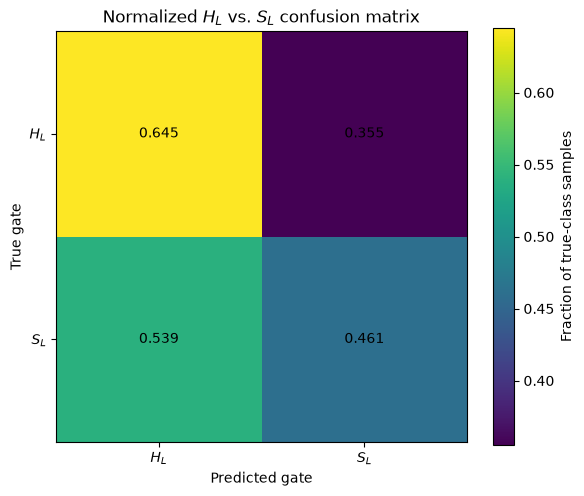

In [65]:
# Plot the normalized confusion matrix for the main H_L vs S_L
# classification experiment. Normalization is performed row-wise,
# so each row represents the prediction distribution for one true gate.

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_normalized)

plt.colorbar(label="Fraction of true-class samples")

plt.xticks(
    [0, 1],
    [r"$H_L$", r"$S_L$"]
)

plt.yticks(
    [0, 1],
    [r"$H_L$", r"$S_L$"]
)

plt.xlabel("Predicted gate")
plt.ylabel("True gate")
plt.title(r"Normalized $H_L$ vs. $S_L$ confusion matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**Normalized confusion matrix**

The normalized confusion matrix shows the conditional prediction frequencies for the two logical gates.

For true $H_L$ records,

$$
P(\widehat{G}=H_L\mid G=H_L)=0.645,
$$

while

$$
P(\widehat{G}=S_L\mid G=H_L)=0.355.
$$

For true $S_L$ records,

$$
P(\widehat{G}=H_L\mid G=S_L)=0.539,
$$

and

$$
P(\widehat{G}=S_L\mid G=S_L)=0.461.
$$

Thus, the classifier identifies $H_L$ more frequently than $S_L$ in this experiment. The asymmetry is also reflected in the class-specific recalls:

$$
\mathrm{Recall}(H_L)=0.645,
\qquad
\mathrm{Recall}(S_L)=0.461.
$$

The normalized confusion matrix therefore confirms that the measured $55.27\%$ overall accuracy is not distributed equally between the two gate classes.

**Temporal contribution to gate inference**

The fingerprint analysis showed that the largest $H_L$–$S_L$ event-rate differences occur at $t=1.0$.

We now test whether this temporal layer also provides the main contribution to gate inference.

The complete detector record is divided into three feature subsets according to detector time:

$$
t=0,\qquad t=1,\qquad t=1.5.
$$

A Bernoulli Naive Bayes classifier is trained and evaluated separately using the detector subset from each temporal layer.

This temporal ablation experiment provides a direct comparison between the gate-dependent detector statistics and their usefulness for inference. In particular, it tests whether the layer with the largest fingerprint difference also produces the strongest classification signal.

In [66]:
# Create detector-index groups for each temporal layer.
# These groups allow us to train the same classifier using one temporal
# layer at a time and determine which part of the detector record carries
# the strongest gate-dependent signal.

time_to_indices = {}

for t in time_slices:
    time_to_indices[t] = np.array([
        detector_id
        for detector_id, coord in h_detector_coords.items()
        if coord[2] == t
    ], dtype=int)

print("Detector indices by temporal layer:")

for t in sorted(time_to_indices):
    print(
        f"t = {t}: "
        f"{len(time_to_indices[t])} detectors"
    )

Detector indices by temporal layer:
t = 0.0: 40 detectors
t = 1.0: 40 detectors
t = 1.5: 20 detectors


In [67]:
# Evaluate Bernoulli Naive Bayes using each temporal layer independently.
# The same train/test split is reused so that the layer-wise accuracies
# can be compared under identical test samples.

temporal_accuracy = {}

for t in sorted(time_to_indices):
    indices = time_to_indices[t]

    X_train_t = X_train[:, indices]
    X_test_t = X_test[:, indices]

    temporal_classifier = BernoulliNB()
    temporal_classifier.fit(X_train_t, y_train)

    y_pred_t = temporal_classifier.predict(X_test_t)

    accuracy_t = accuracy_score(y_test, y_pred_t)
    temporal_accuracy[t] = accuracy_t

    print(
        f"t = {t}: "
        f"{len(indices)} detectors, "
        f"accuracy = {accuracy_t:.4f}"
    )

t = 0.0: 40 detectors, accuracy = 0.5102
t = 1.0: 40 detectors, accuracy = 0.5473
t = 1.5: 20 detectors, accuracy = 0.5065


**Statistical significance of temporal-layer inference**

The temporal-layer analysis showed that the highest classification accuracy occurs at $t=1.0$:

$$
\mathrm{Accuracy}_{t=0}=0.5102,
$$

$$
\mathrm{Accuracy}_{t=1}=0.5473,
$$

and

$$
\mathrm{Accuracy}_{t=1.5}=0.5065.
$$

To determine whether these deviations from the $50\%$ chance level are statistically distinguishable from random classification, an exact one-sided binomial test is applied independently to the predictions from each temporal layer.

The null hypothesis is

$$
H_0:p=0.5,
$$

where $p$ is the probability of a correct classification under the chance-level model.

This analysis tests whether the gate-dependent information observed in each temporal layer provides evidence of above-chance classification under the present simulation and classifier.

**Statistical testing of individual temporal layers**

The temporal-layer gate-inference experiment evaluates whether individual spacetime layers contain information that can distinguish $H_L$ from $S_L$.

For each temporal layer $t$, let

$$
n_t
$$

denote the number of test records and

$$
k_t
$$

the number of correctly classified records. The observed accuracy is

$$
\widehat{p}_t=\frac{k_t}{n_t}.
$$

Because the test set contains two equally likely gate classes, the chance-level accuracy is

$$
p_0=0.5.
$$

For each temporal layer, we therefore perform a one-sided exact binomial test:

$$
H_0:p_t=0.5,
\qquad
H_1:p_t>0.5.
$$

A 95% Wilson confidence interval is also calculated for each observed accuracy. The confidence intervals quantify the uncertainty in the measured accuracy, while the binomial test evaluates whether the observed number of correct classifications is inconsistent with the $50\%$ chance-level hypothesis.

The three temporal layers are tested independently:

$$
t=0.0,\qquad t=1.0,\qquad t=1.5.
$$

These tests allow the statistical evidence for gate-dependent information to be compared across the decoding window.

In [71]:
# Evaluate gate inference independently at each temporal layer.
# The Wilson confidence interval is computed directly to avoid requiring
# the optional statsmodels package.

from scipy.stats import binomtest
from sklearn.naive_bayes import BernoulliNB
import numpy as np

def wilson_interval(k, n, confidence=0.95):
    """Return a two-sided Wilson confidence interval for a binomial proportion."""
    p_hat = k / n

    # Standard normal critical value for a two-sided 95% interval.
    z = 1.959963984540054

    z2 = z**2

    center = (
        p_hat + z2 / (2 * n)
    ) / (
        1 + z2 / n
    )

    half_width = (
        z
        * np.sqrt(
            p_hat * (1 - p_hat) / n
            + z2 / (4 * n**2)
        )
        / (
            1 + z2 / n
        )
    )

    return center - half_width, center + half_width


print("Statistical testing by temporal layer:\n")

temporal_statistics = {}

for t in sorted(time_to_indices):
    indices = time_to_indices[t]

    # Train and test using only detectors belonging to this temporal layer.
    X_train_t = X_train[:, indices]
    X_test_t = X_test[:, indices]

    classifier_t = BernoulliNB()
    classifier_t.fit(X_train_t, y_train)

    y_pred_t = classifier_t.predict(X_test_t)

    n_t = len(y_test)
    k_t = np.sum(y_pred_t == y_test)
    accuracy_t = k_t / n_t

    # Exact one-sided test against the 50% chance level.
    test_result = binomtest(
        k_t,
        n=n_t,
        p=0.5,
        alternative="greater"
    )

    # Conventional two-sided 95% Wilson confidence interval.
    ci_low, ci_high = wilson_interval(k_t, n_t, confidence=0.95)

    temporal_statistics[t] = {
        "correct": k_t,
        "n": n_t,
        "accuracy": accuracy_t,
        "p_value": test_result.pvalue,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }

    print(f"t = {t}:")
    print(f"  Correct:  {k_t} / {n_t}")
    print(f"  Accuracy: {accuracy_t:.4f}")
    print(f"  95% CI:   [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  p-value:  {test_result.pvalue:.6g}")
    print()


Statistical testing by temporal layer:

t = 0.0:
  Correct:  2041 / 4000
  Accuracy: 0.5102
  95% CI:   [0.4948, 0.5257]
  p-value:  0.100143

t = 1.0:
  Correct:  2189 / 4000
  Accuracy: 0.5473
  95% CI:   [0.5318, 0.5626]
  p-value:  1.22171e-09

t = 1.5:
  Correct:  2026 / 4000
  Accuracy: 0.5065
  95% CI:   [0.4910, 0.5220]
  p-value:  0.210013



**Gate inference by temporal layer**

To identify which part of the detector record carries the gate-dependent information, gate inference was evaluated separately for each temporal layer.

The results are:

$$
\begin{array}{c|c|c|c}
t & \text{Correct} & \text{Accuracy} & p\text{-value} \\
\hline
0.0 & 2041/4000 & 0.5102 & 0.100143 \\
1.0 & 2189/4000 & 0.5473 & 1.22171\times10^{-9} \\
1.5 & 2026/4000 & 0.5065 & 0.210013
\end{array}
$$

The $t=0.0$ and $t=1.5$ layers do not show statistically significant evidence of accuracy above the $50\%$ chance level in this experiment.

In contrast, the $t=1.0$ layer achieves an accuracy of

$$
0.5473,
$$

with a one-sided binomial-test $p$-value of

$$
1.22171\times10^{-9}.
$$

The corresponding 95% confidence interval is

$$
[0.5318,\;0.5626],
$$

which lies above the $50\%$ chance level.

The temporal analysis therefore localizes the statistically detectable gate-dependent information primarily to the $t=1.0$ detector layer in the present simulation.

This result is consistent with the earlier fingerprint analysis, where the largest $H_L$–$S_L$ differences were also concentrated at $t=1.0$. It does not imply that the entire $H_L$–$S_L$ distinction is generated exclusively by this layer, but it indicates that this layer carries the strongest detectable classification signal under the present noise model and classifier.

In [74]:
# Recompute the overall accuracy uncertainty using a two-sided 95% Wilson
# confidence interval. The earlier binomial test used a one-sided alternative
# because the hypothesis of interest was accuracy greater than the 50% chance level.

from scipy.stats import binomtest

n_test = len(y_test)
n_correct = np.sum(y_pred == y_test)

overall_test = binomtest(
    n_correct,
    n=n_test,
    p=0.5,
    alternative="greater"
)

overall_ci_two_sided = binomtest(
    n_correct,
    n=n_test,
    p=0.5,
    alternative="two-sided"
).proportion_ci(
    confidence_level=0.95,
    method="wilson"
)

print("Overall gate-inference statistics:")
print(f"Accuracy: {n_correct / n_test:.6f}")
print(
    f"95% two-sided Wilson CI: "
    f"[{overall_ci_two_sided.low:.6f}, {overall_ci_two_sided.high:.6f}]"
)
print(f"One-sided binomial p-value: {overall_test.pvalue:.6g}")

Overall gate-inference statistics:
Accuracy: 0.552750
95% two-sided Wilson CI: [0.537298, 0.568100]
One-sided binomial p-value: 1.3449e-11


**Temporal localization of gate-inference accuracy**

The classification results are summarized by temporal layer to visualize where gate-dependent information is detectable.

The chance level for the balanced two-class problem is

$$
\mathrm{Accuracy}_{\mathrm{chance}}=0.50.
$$

The temporal-layer accuracies are

$$
0.5102,\qquad 0.5473,\qquad 0.5065
$$

for $t=0.0$, $t=1.0$, and $t=1.5$, respectively.

The $t=1.0$ layer shows the largest departure from the chance level, consistent with the statistical testing and the earlier detector-fingerprint difference analysis.

**Temporal-layer gate inference**

The previous analysis showed that the largest difference between the $H_L$ and $S_L$ detector-event profiles occurs at $t=1.0$.

To determine whether this temporal localization also affects gate inference, we now train a separate Bernoulli Naive Bayes classifier using only the detectors belonging to each temporal layer.

For a temporal layer $t$, let

$$
\mathcal{D}_t
=
\{j:\operatorname{time}(D_j)=t\}.
$$

The classifier receives only the detector subset

$$
\mathbf{d}_t
=
\{D_j:j\in\mathcal{D}_t\}.
$$

The classification accuracy is then evaluated independently for

$$
t\in\{0,\;1,\;1.5\}.
$$

This experiment tests whether the gate-dependent information is concentrated in a particular temporal portion of the detector record.

The resulting accuracies are compared with the $50\%$ chance level of the balanced two-class problem.

In [79]:
# Train a separate Bernoulli Naive Bayes classifier for each temporal layer.
# Only detectors belonging to the selected time layer are used as features.
# The same train/test split is retained across all temporal-layer models.

temporal_accuracy = {}
temporal_results = {}

for t in time_slices:
    # Identify the detector columns belonging to this temporal layer.
    layer_mask = np.array([
        coord[2] == t
        for coord in h_coords
    ])

    X_train_layer = X_train[:, layer_mask]
    X_test_layer = X_test[:, layer_mask]

    layer_classifier = BernoulliNB()
    layer_classifier.fit(X_train_layer, y_train)

    layer_pred = layer_classifier.predict(X_test_layer)

    layer_accuracy = accuracy_score(
        y_test,
        layer_pred
    )

    temporal_accuracy[t] = layer_accuracy
    temporal_results[t] = {
        "n_detectors": int(layer_mask.sum()),
        "accuracy": layer_accuracy
    }

    print(
        f"t = {t}: "
        f"{int(layer_mask.sum())} detectors, "
        f"accuracy = {layer_accuracy:.4f}"
    )

t = 0.0: 40 detectors, accuracy = 0.5102
t = 1.0: 40 detectors, accuracy = 0.5473
t = 1.5: 20 detectors, accuracy = 0.5065


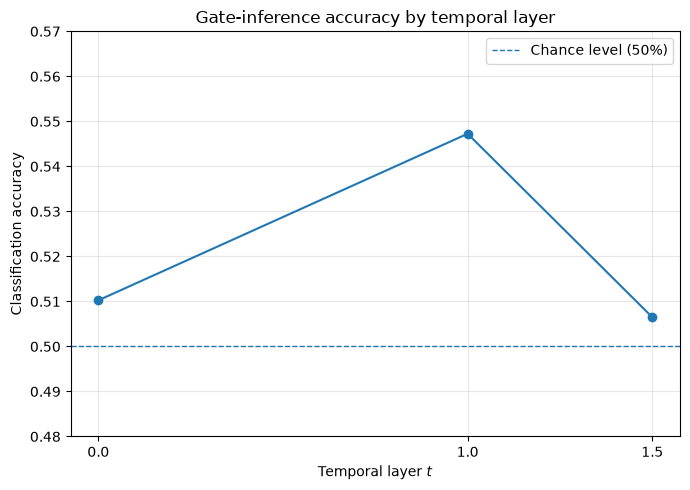

In [77]:
# Plot the classifier accuracy obtained from the actual detector records
# for each temporal layer, together with the 50% chance level.

temporal_times = np.array(sorted(temporal_accuracy.keys()))
temporal_acc_values = np.array([
    temporal_accuracy[t]
    for t in temporal_times
])

plt.figure(figsize=(7, 5))

plt.plot(
    temporal_times,
    temporal_acc_values,
    marker="o",
    linewidth=1.5
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Chance level (50%)"
)

plt.xticks(temporal_times)
plt.xlabel(r"Temporal layer $t$")
plt.ylabel("Classification accuracy")
plt.ylim(0.48, 0.57)
plt.title("Gate-inference accuracy by temporal layer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Inference conclusion for $H_L$ and $S_L$**

The complete detector-record experiment provides evidence that the simulated $H_L$ and $S_L$ operations produce gate-dependent detector statistics.

Using the full 100-detector record, the Bernoulli Naive Bayes baseline achieved an accuracy of $55.27\%$ on the balanced test set, above the $50\%$ chance level. The exact one-sided binomial test against the null hypothesis of chance-level classification gives

$$
p=1.3449\times10^{-11}.
$$

The temporal ablation further localizes the strongest classification signal to the $t=1.0$ detector layer, where the measured accuracy is $54.73\%$.

Together with the detector-event probability analysis, these results establish a measurable $H_L$–$S_L$ detector fingerprint difference in the present noisy simulation.

This experiment is a baseline demonstration of gate-dependent information leakage. It does not quantify the optimal possible inference accuracy, since the classifier assumes conditional independence of detector features and the analysis uses only the simulated noise model and circuit implementation examined here.